In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# IMPORTS
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant
from statsmodels.tsa.ardl import ARDL, ardl_select_order
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from scipy import stats
import ruptures as rpt
import yfinance as yf

# ══════════════════════════════════════════════════════════════════════════════
# CELL 1 — SETTINGS
# ══════════════════════════════════════════════════════════════════════════════

PERIOD_BOUNDS = {
    'Pre-Shock':   ('2015-01-01', '2020-01-29'),
    'COVID':       ('2020-01-30', '2022-02-21'),
    'RU-War':      ('2022-02-22', '2025-12-31'),

}

PERIOD_SHORT = {
    'Pre-Shock':   'Pre-Shock',
    'COVID':       'COVID',
    'RU-War':      'RU-War',
}

OIL      = 'ln_Brent'
FX       = ['ln_CAD', 'ln_EUR', 'ln_BRL', 'ln_ZAR']
CONTROLS = ['ln_DXY', 'ln_VIX']
SHORT    = {'ln_CAD':'CAD','ln_EUR':'EUR','ln_BRL':'BRL','ln_ZAR':'ZAR'}
FX_TYPE  = {
    'ln_CAD': 'Developed (Exporter)',
    'ln_EUR': 'Developed (Importer)',
    'ln_BRL': 'Emerging (Exporter)',
    'ln_ZAR': 'Emerging (Mixed)'
}

CRIT_LOWER = 3.79
CRIT_UPPER = 4.85

pd.set_option('display.float_format', '{:.4f}'.format)

# ══════════════════════════════════════════════════════════════════════════════
# CELL 2 — DATA DOWNLOAD
# ══════════════════════════════════════════════════════════════════════════════

TICKER_MAP = {
    'Brent'  : 'BZ=F',
    'CAD'    : 'CAD=X',
    'EUR_raw': 'EURUSD=X',
    'BRL'    : 'BRL=X',
    'ZAR'    : 'ZAR=X',
    'DXY'    : 'DX-Y.NYB',
    'VIX'    : '^VIX'
}

raw_download = yf.download(
    list(TICKER_MAP.values()),
    start='2015-01-01',
    end='2025-12-31',
    auto_adjust=True,
    progress=False
)['Close']

ticker_to_name = {v: k for k, v in TICKER_MAP.items()}
raw_download.columns = [
    ticker_to_name[col] if col in ticker_to_name else col
    for col in raw_download.columns
]

raw = raw_download[list(TICKER_MAP.keys())].copy()
raw['EUR'] = 1.0 / raw['EUR_raw']
raw = raw.drop(columns=['EUR_raw'])
raw = raw.ffill().dropna()

# Verify
print("Data verification:")
print(f"Brent mean: {raw['Brent'].mean():.2f} (expected ~66)")
print(f"CAD mean:   {raw['CAD'].mean():.4f} (expected ~1.32)")
print(f"EUR mean:   {raw['EUR'].mean():.4f} (expected ~0.89)")
print(f"BRL mean:   {raw['BRL'].mean():.4f} (expected ~4.48)")
print(f"ZAR mean:   {raw['ZAR'].mean():.4f} (expected ~15.50)")
print(f"DXY mean:   {raw['DXY'].mean():.2f} (expected ~98.32)")
print(f"VIX mean:   {raw['VIX'].mean():.2f} (expected ~18.30)")
print(f"\nFull sample: {raw.index[0].date()} to {raw.index[-1].date()} ({len(raw)} obs)")

# Log transform
log_data = np.log(raw)
log_data.columns = [f'ln_{c}' for c in raw.columns]

# Period slices
periods = {'Full Sample': log_data}
for name, (s, e) in PERIOD_BOUNDS.items():
    periods[name] = log_data.loc[s:e].copy()

print("\nObservations by period:")
for name, df in periods.items():
    print(f"  {name}: {len(df)} obs")

# ══════════════════════════════════════════════════════════════════════════════
# CELL 3 — UNIT ROOT TESTS (ADF + PP)
# ══════════════════════════════════════════════════════════════════════════════

from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron

def run_unit_root(series, name):
    # ADF
    adf_level = adfuller(series, autolag='BIC')
    adf_diff  = adfuller(series.diff().dropna(), autolag='BIC')
    # PP
    pp_level = PhillipsPerron(series)
    pp_diff  = PhillipsPerron(series.diff().dropna())

    adf_l_sig = '***' if adf_level[1]<0.01 else '**' if adf_level[1]<0.05 else '*' if adf_level[1]<0.10 else ''
    adf_d_sig = '***' if adf_diff[1]<0.01  else '**' if adf_diff[1]<0.05  else '*' if adf_diff[1]<0.10  else ''
    pp_l_sig  = '***' if pp_level.pvalue<0.01  else '**' if pp_level.pvalue<0.05  else '*' if pp_level.pvalue<0.10  else ''
    pp_d_sig  = '***' if pp_diff.pvalue<0.01   else '**' if pp_diff.pvalue<0.05   else '*' if pp_diff.pvalue<0.10   else ''

    order = 'I(0)' if adf_level[1]<0.05 else 'I(1)'

    print(f"{name:<12} ADF Level: {adf_level[0]:8.3f}{adf_l_sig:<3} "
          f"ADF Diff: {adf_diff[0]:8.3f}{adf_d_sig:<3} "
          f"PP Level: {pp_level.stat:8.3f}{pp_l_sig:<3} "
          f"PP Diff: {pp_diff.stat:8.3f}{pp_d_sig:<3} "
          f"Order: {order}")

print("Unit Root Tests")
print("="*100)
for var in [OIL] + FX + CONTROLS:
    run_unit_root(log_data[var].dropna(), var.replace('ln_',''))

# ══════════════════════════════════════════════════════════════════════════════
# CELL 4 — STRUCTURAL BREAK TESTS
# ══════════════════════════════════════════════════════════════════════════════

def chow_test(data, oil, fx, break_date):
    d  = data[[oil, fx]].dropna()
    bd = pd.Timestamp(break_date)
    pre  = d[d.index < bd]
    post = d[d.index >= bd]
    if len(pre) < 30 or len(post) < 30:
        return np.nan, np.nan
    def ssr(df):
        return OLS(df.iloc[:,1], add_constant(df.iloc[:,0])).fit().ssr
    k = 2; n = len(d)
    F = ((ssr(d)-ssr(pre)-ssr(post))/k) / ((ssr(pre)+ssr(post))/(n-2*k))
    p = 1 - stats.f.cdf(F, k, n-2*k)
    return round(F,3), round(p,4)

# Bai-Perron
print("Bai-Perron Endogenous Break Detection (n_bkps=2, on OLS residuals)")
print("="*65)
for fx_var in FX:
    sub   = log_data[[OIL, fx_var]].dropna()
    resid = OLS(sub[fx_var], add_constant(sub[OIL])).fit().resid.values.reshape(-1,1)
    algo  = rpt.Binseg(model='l2', min_size=50).fit(resid)
    bkps  = algo.predict(n_bkps=2)
    dates = [sub.index[i-1].strftime('%Y-%m-%d') for i in bkps[:-1]]
    print(f"  Brent-{SHORT[fx_var]}: breaks at {dates}")

# Chow Test
print("\nChow Structural Break Test")
print("="*70)
print(f"{'Pair':<18} {'Event':<28} {'F-Stat':>8} {'p-value':>9} {'Sig'}")
print("-"*70)
for fx_var in FX:
    for event, bdate in [
        ('COVID-19 Onset (2020-01-30)', '2020-01-30'),
        ('Russia-Ukraine (2022-02-22)',  '2022-02-22')
    ]:
        F, p = chow_test(log_data, OIL, fx_var, bdate)
        sig  = '***' if p<.01 else '**' if p<.05 else '*' if p<.10 else ''
        print(f"Brent-{SHORT[fx_var]:<12} {event:<28} {F:>8} {p:>9} {sig}")

# ══════════════════════════════════════════════════════════════════════════════
# CELL 5 — LINEARITY TESTS (RESET + BDS)
# ══════════════════════════════════════════════════════════════════════════════

from statsmodels.stats.diagnostic import linear_reset
from statsmodels.tsa.stattools import bds as bds_test

print("Linearity Tests — Ramsey RESET and BDS (Full Sample)")
print("="*80)
print(f"{'Pair':<15} {'RESET F':>9} {'RESET p':>9} {'RESET Sig':>10} "
      f"{'BDS z':>9} {'BDS p':>9} {'BDS Sig':>8} {'Type'}")
print("-"*80)

for fx_var in FX:
    d     = log_data[[OIL, fx_var] + CONTROLS].dropna()
    model = OLS(d[fx_var], add_constant(d[[OIL]+CONTROLS])).fit()

    # RESET test
    reset = linear_reset(model, power=2, use_f=True)
    r_sig = '***' if reset.pvalue<0.01 else '**' if reset.pvalue<0.05 else '*' if reset.pvalue<0.10 else ''

    # BDS test on residuals
    try:
        bds_result = bds(model.resid.values, max_dim=2)
        bds_z = bds_result.stat[0]
        bds_p = bds_result.pvalue[0]
    except:
        # Alternative import path
        try:
            from statsmodels.tsa.stattools import bds as bds_alt
            bds_result = bds_alt(model.resid.values, max_dim=2)
            bds_z = bds_result[0][0]
            bds_p = bds_result[1][0]
        except:
            bds_z = np.nan
            bds_p = np.nan

    b_sig    = '***' if bds_p<0.01 else '**' if bds_p<0.05 else '*' if bds_p<0.10 else ''
    rel_type = 'Nonlinear' if reset.pvalue<0.05 or bds_p<0.05 else 'Linear'

    print(f"Brent-{SHORT[fx_var]:<9} {reset.fvalue:>9.3f} {reset.pvalue:>9.4f} {r_sig:>10} "
          f"{bds_z:>9.3f} {bds_p:>9.4f} {b_sig:>8} {rel_type}")

# ══════════════════════════════════════════════════════════════════════════════
# CELL 6 — LAG SELECTION (BIC)
# ══════════════════════════════════════════════════════════════════════════════

from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant

def compute_bic_ardl(data, oil, fx, controls, p):
    """
    Manually compute BIC for ARDL(p,p) model.
    y_t = const + rho*y_{t-1} + sum(dy_{t-i}) +
          theta+*oil+_{t-1} + theta-*oil-_{t-1} +
          sum(d_oil+_{t-i}) + sum(d_oil-_{t-i}) + controls + e_t
    """
    d = data[[oil, fx] + controls].dropna().copy()

    # Create partial sums
    d_oil = d[oil].diff()
    oil_p = d_oil.clip(lower=0).cumsum()
    oil_n = d_oil.clip(upper=0).cumsum()

    # Build regressor list
    regs = {}

    # Lagged levels
    regs['y_lag1']    = d[fx].shift(1)
    regs['oil_p_lag1'] = oil_p.shift(1)
    regs['oil_n_lag1'] = oil_n.shift(1)

    # Lagged differences of y
    for i in range(1, p+1):
        regs[f'dy_lag{i}'] = d[fx].diff().shift(i)

    # Lagged differences of oil+ and oil-
    for i in range(0, p+1):
        regs[f'doilp_lag{i}'] = d_oil.clip(lower=0).shift(i)
        regs[f'doiln_lag{i}'] = d_oil.clip(upper=0).shift(i)

    # Controls
    for ctrl in controls:
        regs[ctrl] = d[ctrl]

    X = pd.DataFrame(regs)
    y = d[fx]

    # Align
    df = pd.concat([y, X], axis=1).dropna()
    y_clean = df.iloc[:, 0]
    X_clean = add_constant(df.iloc[:, 1:])

    res = OLS(y_clean, X_clean).fit()

    n   = len(y_clean)
    k   = X_clean.shape[1]
    bic = n * np.log(res.ssr/n) + k * np.log(n)

    return bic, n

print("Lag Length Selection — BIC Criterion")
print("="*75)
print(f"{'Pair':<15} {'P=1':>10} {'P=2':>10} {'P=3':>10} "
      f"{'P=4':>10} {'P=5':>10} {'Selected':>10}")
print("-"*75)

selected_lags = {}

for fx_var in FX:
    bics = []
    for p in range(1, 6):
        try:
            bic, n = compute_bic_ardl(
                log_data, OIL, fx_var, CONTROLS, p
            )
            bics.append(bic)
        except Exception as e:
            bics.append(np.nan)

    # Select best lag
    valid = [(i, b) for i, b in enumerate(bics) if not np.isnan(b)]
    if valid:
        best_idx = min(valid, key=lambda x: x[1])[0]
        best_lag = best_idx + 1
    else:
        best_lag = 1

    selected_lags[fx_var] = best_lag

    # Format output
    bic_vals = [f'{b:.2f}' if not np.isnan(b) else 'N/A' for b in bics]
    print(f"Brent-{SHORT[fx_var]:<9} "
          f"{bic_vals[0]:>10} {bic_vals[1]:>10} {bic_vals[2]:>10} "
          f"{bic_vals[3]:>10} {bic_vals[4]:>10} {best_lag:>10}")

print(f"\nSelected lags: {selected_lags}")

# ══════════════════════════════════════════════════════════════════════════════
# CELL 7 — NARDL ESTIMATION (FIXED)
# ══════════════════════════════════════════════════════════════════════════════

def run_nardl(data, oil, fx, controls, lag=1):
    """Run NARDL and return key results."""
    d = data[[oil, fx] + controls].dropna().copy()

    if len(d) < 50:
        return None

    # Oil log returns
    d_oil = d[oil].diff()

    # Partial sum decomposition
    oil_p = d_oil.clip(lower=0).cumsum()
    oil_n = d_oil.clip(upper=0).cumsum()
    oil_p.name = 'oil_pos'
    oil_n.name = 'oil_neg'

    # Build regressor dataframe
    reg_dict = {}

    # ECM levels (lagged)
    reg_dict['y_L1']      = d[fx].shift(1)
    reg_dict['oil_pos_L1'] = oil_p.shift(1)
    reg_dict['oil_neg_L1'] = oil_n.shift(1)

    # Lagged differences of y
    for i in range(1, lag+1):
        reg_dict[f'dy_L{i}'] = d[fx].diff().shift(i)

    # Contemporaneous and lagged differences of oil+ and oil-
    reg_dict['doil_pos_L0'] = d_oil.clip(lower=0)
    reg_dict['doil_neg_L0'] = d_oil.clip(upper=0)
    for i in range(1, lag+1):
        reg_dict[f'doil_pos_L{i}'] = d_oil.clip(lower=0).shift(i)
        reg_dict[f'doil_neg_L{i}'] = d_oil.clip(upper=0).shift(i)

    # Controls (level)
    for ctrl in controls:
        reg_dict[ctrl] = d[ctrl]

    # Combine
    X = pd.DataFrame(reg_dict)
    y = d[fx].diff()

    df = pd.concat([y, X], axis=1).dropna()
    y_clean = df.iloc[:, 0]
    X_clean = add_constant(df.iloc[:, 1:])

    if len(y_clean) < 20:
        return None

    res = OLS(y_clean, X_clean).fit(cov_type='HC1')

    # Extract coefficients by name
    params = res.params
    n      = len(y_clean)

    try:
        rho     = float(params['y_L1'])
        theta_p = float(params['oil_pos_L1'])
        theta_n = float(params['oil_neg_L1'])
    except KeyError as e:
        print(f"KeyError: {e} | Available: {list(params.index)}")
        return None

    if abs(rho) < 1e-10:
        return None

    L_plus  = round(-theta_p / rho, 4)
    L_minus = round(-theta_n / rho, 4)

    # Bounds F-test: H0: rho = theta+ = theta- = 0
    cols     = list(X_clean.columns)
    n_params = len(cols)

    r_mat = np.zeros((3, n_params))
    for i, name in enumerate(['y_L1', 'oil_pos_L1', 'oil_neg_L1']):
        if name in cols:
            r_mat[0 if name=='y_L1' else 1 if name=='oil_pos_L1' else 2, i] = 1

    try:
        f_test   = res.f_test(r_mat)
        bounds_F = float(np.squeeze(f_test.fvalue))
    except:
        bounds_F = np.nan

    # Wald test: H0: theta+ = theta-
    r_wald = np.zeros(n_params)
    for i, name in enumerate(cols):
        if name == 'oil_pos_L1':
            r_wald[i] =  1
        if name == 'oil_neg_L1':
            r_wald[i] = -1

    try:
        wald   = res.f_test(r_wald)
        wald_p = float(np.squeeze(wald.pvalue))
    except:
        wald_p = np.nan

    return {
        'L+':      L_plus,
        'L-':      L_minus,
        'Bounds F': round(bounds_F, 3),
        'Wald p':   round(wald_p, 4),
        'N':        n
    }

# ── Run with controls ─────────────────────────────────────────────────────────
PERIOD_ORDER = ['Full Sample', 'Pre-Shock', 'COVID', 'RU-War']

period_data = {
    'Full Sample': log_data,
    'Pre-Shock':   periods['Pre-Shock'],
    'COVID':       periods['COVID'],
    'RU-War':      periods['RU-War'],
}

print("NARDL WITH CONTROLS")
print("="*105)
print(f"{'Period':<22} {'Pair':<12} {'L+':>8} {'L-':>8} "
      f"{'Bounds F':>10} {'LR Rel.':>12} {'Wald p':>10} {'Asym':>6} {'N':>6}")
print("-"*105)

nardl_results = {}

for period_name in PERIOD_ORDER:
    data = period_data[period_name]
    nardl_results[period_name] = {}

    for fx_var in FX:
        result = run_nardl(data, OIL, fx_var, CONTROLS, lag=1)

        if result is None:
            print(f"{period_name:<22} Brent-{SHORT[fx_var]:<6} FAILED")
            continue

        nardl_results[period_name][fx_var] = result

        F  = result['Bounds F']
        if np.isnan(F):
            lr = 'N/A'
        elif F > CRIT_UPPER:
            lr = 'CI (5%)'
        elif F < CRIT_LOWER:
            lr = 'No CI'
        else:
            lr = 'Inconclusive'

        wp   = result['Wald p']
        asym = '***' if wp<0.01 else '**' if wp<0.05 else '*' if wp<0.10 else 'No'

        print(f"{period_name:<22} Brent-{SHORT[fx_var]:<6} "
              f"{result['L+']:>8.4f} {result['L-']:>8.4f} "
              f"{F:>10.3f} {lr:>12} {wp:>10.4f} {asym:>6} {result['N']:>6}")

# ── Run without controls ──────────────────────────────────────────────────────
print("\nNARDL WITHOUT CONTROLS")
print("="*105)
print(f"{'Period':<22} {'Pair':<12} {'L+':>8} {'L-':>8} "
      f"{'Bounds F':>10} {'LR Rel.':>12} {'Wald p':>10} {'Asym':>6} {'N':>6}")
print("-"*105)

for period_name in PERIOD_ORDER:
    data = period_data[period_name]

    for fx_var in FX:
        result = run_nardl(data, OIL, fx_var, [], lag=1)

        if result is None:
            print(f"{period_name:<22} Brent-{SHORT[fx_var]:<6} FAILED")
            continue

        F  = result['Bounds F']
        if np.isnan(F):
            lr = 'N/A'
        elif F > CRIT_UPPER:
            lr = 'CI (5%)'
        elif F < CRIT_LOWER:
            lr = 'No CI'
        else:
            lr = 'Inconclusive'

        wp   = result['Wald p']
        asym = '***' if wp<0.01 else '**' if wp<0.05 else '*' if wp<0.10 else 'No'

        print(f"{period_name:<22} Brent-{SHORT[fx_var]:<6} "
              f"{result['L+']:>8.4f} {result['L-']:>8.4f} "
              f"{F:>10.3f} {lr:>12} {wp:>10.4f} {asym:>6} {result['N']:>6}")

# ── Fixed Markov Switching Parameter Extraction ──────────────────────────────
print("\nTable: Markov Regime-Switching Parameter Summary")
print("="*80)
print(f"{'Currency':<8} {'Type':<22} {'Regime':<10} {'β_Brent':>10} "
      f"{'σ (vol)':>10} {'P(stay)':>10} {'E[Days]':>10}")
print("-"*80)

for fx_var, currency_name, economy_type in [
    ('ln_CAD', 'CAD', 'Developed (Exporter)'),
    ('ln_EUR', 'EUR', 'Developed (Importer)'),
    ('ln_BRL', 'BRL', 'Emerging (Exporter)'),
    ('ln_ZAR', 'ZAR', 'Emerging (Mixed)')
]:
    try:
        d = log_data[[OIL, fx_var]].dropna()
        y = d[fx_var].values
        x = d[OIL].values

        from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
        model = MarkovRegression(y, k_regimes=2, exog=x,
                                switching_variance=True,
                                switching_exog=True)
        result = model.fit(search_reps=20, disp=False)

        params = result.params

        for regime in range(2):
            # Extract parameters using correct key names
            beta = params[f'x1[{regime}]']
            sigma2 = params[f'sigma2[{regime}]']
            sigma = np.sqrt(sigma2)
            p_stay = params[f'p[{regime}->{regime}]'] if f'p[{regime}->{regime}]' in params.index else 1 - params[f'p[{1-regime}->{regime}]']
            e_days = 1 / (1 - p_stay) if p_stay < 1 else np.inf

            print(f"{currency_name:<8} {economy_type:<22} "
                  f"Regime {regime+1}   "
                  f"{beta:>10.4f} {sigma:>10.5f} "
                  f"{p_stay:>10.3f} {e_days:>10.1f}")

    except Exception as e:
        print(f"{currency_name}: Error - {e}")

Data verification:
Brent mean: 66.58 (expected ~66)
CAD mean:   1.3215 (expected ~1.32)
EUR mean:   0.8947 (expected ~0.89)
BRL mean:   4.4782 (expected ~4.48)
ZAR mean:   15.5033 (expected ~15.50)
DXY mean:   98.32 (expected ~98.32)
VIX mean:   18.30 (expected ~18.30)

Full sample: 2015-01-02 to 2025-12-30 (2865 obs)

Observations by period:
  Full Sample: 2865 obs
  Pre-Shock: 1324 obs
  COVID: 538 obs
  RU-War: 1003 obs
Unit Root Tests
Brent        ADF Level:   -2.359    ADF Diff:  -52.939*** PP Level:   -2.373    PP Diff:  -52.950*** Order: I(1)
CAD          ADF Level:   -3.903*** ADF Diff:  -53.999*** PP Level:   -3.940*** PP Diff:  -54.056*** Order: I(0)
EUR          ADF Level:   -3.001**  ADF Diff:  -53.879*** PP Level:   -2.860*   PP Diff:  -54.207*** Order: I(0)
BRL          ADF Level:   -1.937    ADF Diff:  -59.718*** PP Level:   -1.989    PP Diff:  -59.830*** Order: I(1)
ZAR          ADF Level:   -2.291    ADF Diff:  -71.194*** PP Level:   -2.315    PP Diff:  -73.085*** Orde

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 16 — MARKOV REGIME-SWITCHING: MODEL FITTING & TABLE 11
# ══════════════════════════════════════════════════════════════════════════════
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
import warnings
warnings.filterwarnings('ignore')

# ── Log-returns (first differences of log-levels) ────────────────────────────
ret       = log_data.diff().dropna()
N_REGIMES = 2
ms_results = {}   # {short_name: fitted model}
ms_rows    = []   # rows for Table 11

print("Fitting Markov Regime-Switching models (2 regimes, switching variance)...")
print("=" * 65)

for fx in FX:
    short = SHORT[fx]
    data  = pd.concat([ret[fx], ret[['ln_Brent', 'ln_DXY', 'ln_VIX']]], axis=1).dropna()

    # ── Markov Switching Regression ───────────────────────────────────────────
    # Δln_FX_t = μ(st) + β_Brent(st)·ΔlnBrent + β_DXY(st)·ΔlnDXY
    #            + β_VIX(st)·ΔlnVIX + ε(st)
    # st ∈ {0,1}, switching_variance=True → σ² also regime-dependent
    model = MarkovRegression(
        data.iloc[:, 0],
        k_regimes=N_REGIMES,
        exog=data.iloc[:, 1:],
        switching_variance=True,
        switching_exog=True
    )
    res = model.fit(disp=False, maxiter=2000)
    ms_results[short] = res

    # ── Extract parameters ────────────────────────────────────────────────────
    params_s = pd.Series(res.params.values, index=res.model.param_names)

    # Transition probabilities (Hamilton 1989 parameterisation)
    p00 = params_s.get('p[0->0]', np.nan)   # P(stay in regime 0)
    p10 = params_s.get('p[1->0]', np.nan)   # P(regime 1 → regime 0)
    p11 = 1.0 - p10 if not np.isnan(p10) else np.nan  # P(stay in regime 1)

    dur_0 = 1.0 / (1 - p00) if (not np.isnan(p00) and p00 < 1) else np.nan
    dur_1 = 1.0 / (1 - p11) if (not np.isnan(p11) and p11 < 1) else np.nan

    for r in range(N_REGIMES):
        # Oil beta — try multiple possible param name formats
        beta_brent = np.nan
        for tag in [f'ln_Brent[{r}]', f'x1[{r}]', f'beta.ln_Brent[{r}]']:
            if tag in params_s.index:
                beta_brent = params_s[tag]; break

        # Volatility (σ = √σ²)
        sigma = np.nan
        for tag in [f'sigma2[{r}]', f'h.{r}', f'var[{r}]']:
            if tag in params_s.index:
                sigma = np.sqrt(abs(params_s[tag])); break

        pii = p00 if r == 0 else p11
        dur = dur_0 if r == 0 else dur_1

        ms_rows.append({
            'Currency': short,
            'Type': FX_TYPE[fx],
            'Regime': f'Regime {r+1}',
            'β_Brent': f'{beta_brent:.4f}' if not np.isnan(beta_brent) else '—',
            'σ (vol)': f'{sigma:.5f}' if not np.isnan(sigma)     else '—',
            'P(stay)': f'{pii:.3f}'   if not np.isnan(pii)        else '—',
            'E[Days]': f'{dur:.1f}'   if not np.isnan(dur)        else '—',
        })

    print(f"  {short:<4} | AIC={res.aic:>10.2f} | BIC={res.bic:>10.2f} | LogL={res.llf:>10.3f}")

print("=" * 65)

# ── Table 11 ─────────────────────────────────────────────────────────────────
ms_table = pd.DataFrame(ms_rows).set_index(['Currency', 'Type', 'Regime'])
print("\nTable 11: Markov Regime-Switching — Parameter Summary")
print(ms_table.to_string())


Fitting Markov Regime-Switching models (2 regimes, switching variance)...
  CAD  | AIC= -23109.27 | BIC= -23037.75 | LogL= 11566.635
  EUR  | AIC= -22594.37 | BIC= -22522.85 | LogL= 11309.186
  BRL  | AIC= -18275.76 | BIC= -18204.24 | LogL=  9149.879
  ZAR  | AIC= -18448.73 | BIC= -18377.21 | LogL=  9236.364

Table 11: Markov Regime-Switching — Parameter Summary
                                        β_Brent  σ (vol) P(stay) E[Days]
Currency Type                 Regime                                    
CAD      Developed (Exporter) Regime 1  -0.0118  0.00335   0.977    42.7
                              Regime 2  -0.0120  0.00601   0.956    22.9
EUR      Developed (Importer) Regime 1  -0.0004  0.00384   0.986    72.2
                              Regime 2   0.0153  0.00741   0.958    23.6
BRL      Emerging (Exporter)  Regime 1  -0.0134  0.00730   0.966    29.4
                              Regime 2  -0.0110  0.01457   0.941    16.9
ZAR      Emerging (Mixed)     Regime 1  -0.0089  0.

In [ ]:
import statsmodels
print(statsmodels.__version__)

# Search for bds
import inspect
import statsmodels.stats
print(dir(statsmodels.stats))

0.14.6
['PytestTester', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_adnorm', '_knockoff', '_lilliefors', '_lilliefors_critical_values', 'contrast', 'diagnostic', 'moment_helpers', 'multitest', 'sandwich_covariance', 'tabledist', 'test']


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 10 — NARDL ESTIMATION (ALL PAIRS × ALL PERIODS + FULL SAMPLE) WITH CONTROL
# ══════════════════════════════════════════════════════════════════════════════
def partial_sums(series):
    d = series.diff()
    return d.clip(lower=0).cumsum(), d.clip(upper=0).cumsum()

def nardl(y, x, z1=None, z2=None, p=2, q=2):
    # NARDL(p,q) with optional exogenous controls z1, z2. Returns result dict.
    xp, xn = partial_sums(x)
    xp.name, xn.name = 'xp', 'xn'

    base = pd.concat([y, x, xp, xn], axis=1).dropna()
    if z1 is not None: base = pd.concat([base, z1], axis=1).dropna()
    if z2 is not None: base = pd.concat([base, z2], axis=1).dropna()

    dy  = base[y.name].diff()
    dxp = xp.reindex(base.index).diff()
    dxn = xn.reindex(base.index).diff()

    regs = pd.DataFrame(index=base.index)
    regs['y_l1']  = base[y.name].shift(1)
    regs['xp_l1'] = xp.reindex(base.index).shift(1)
    regs['xn_l1'] = xn.reindex(base.index).shift(1)
    for i in range(1, p+1):
        regs[f'dy_l{i}'] = dy.shift(i)
    for i in range(0, q+1):
        regs[f'dxp_l{i}'] = dxp.shift(i)
        regs[f'dxn_l{i}'] = dxn.shift(i)
    if z1 is not None: regs[z1.name] = base[z1.name]
    if z2 is not None: regs[z2.name] = base[z2.name]

    all_ = pd.concat([dy.rename('dy'), regs], axis=1).dropna()
    Y_   = all_['dy']
    X_   = add_constant(all_.drop('dy', axis=1))
    m    = OLS(Y_, X_).fit(cov_type='HC1')

    rho  = m.params.get('y_l1', np.nan)
    th_p = m.params.get('xp_l1', np.nan)
    th_n = m.params.get('xn_l1', np.nan)
    Lp   = -th_p/rho if abs(rho) > 1e-8 else np.nan
    Ln   = -th_n/rho if abs(rho) > 1e-8 else np.nan

    # Bounds F-test (joint: y_l1 = xp_l1 = xn_l1 = 0)
    try:
        idx = list(m.params.index)
        R   = np.zeros((3, len(m.params)))
        for j, v in enumerate(['y_l1','xp_l1','xn_l1']):
            if v in idx: R[j, idx.index(v)] = 1
        bounds_F = float(m.wald_test(R).statistic) / 3
    except: bounds_F = np.nan

    # Long-run symmetry Wald: L+ == L- ↔ theta+/rho == theta-/rho ↔ theta+ == theta-
    try:
        idx = list(m.params.index)
        R2  = np.zeros((1, len(m.params)))
        R2[0, idx.index('xp_l1')] =  1
        R2[0, idx.index('xn_l1')] = -1
        wt = m.wald_test(R2)
        lr_F, lr_p = float(wt.statistic), float(wt.pvalue)
    except: lr_F = lr_p = np.nan

    return {'model':m, 'rho':rho, 'theta_pos':th_p, 'theta_neg':th_n,
            'Lpos':Lp, 'Lneg':Ln, 'bounds_F':bounds_F,
            'lr_F':lr_F, 'lr_p':lr_p,
            'asym': lr_p<0.05 if not np.isnan(lr_p) else False,
            'n':len(Y_), 'p':p, 'q':q}

# Pesaran et al. (2001) bounds CV, k=2 (unrestricted intercept, Case III)
BOUNDS_CV = {0.10:(3.17, 3.83), 0.05:(3.79, 4.85), 0.01:(5.15, 6.36)}

nardl_store = {}   # {(period, fx_var): result}
nardl_rows  = []

all_periods = {'Full Sample': log_data}
all_periods.update(periods)

for pn, df in all_periods.items():
    if len(df) < 80: continue
    for fx_var in FX:
        lag = selected_lags.get(fx_var, 1)
        try:
            res = nardl(df[fx_var], df[OIL],
                        z1=df['ln_DXY'], z2=df['ln_VIX'],
                        p=lag, q=lag)
        except Exception as e:
            res = {'Lpos':np.nan,'Lneg':np.nan,'bounds_F':np.nan,
                   'lr_F':np.nan,'lr_p':np.nan,'asym':False,'n':0,'p':lag,'q':lag}
        nardl_store[(pn, fx_var)] = res

        f_   = res['bounds_F']
        cv0, cv1 = BOUNDS_CV[0.05]
        if np.isnan(f_):    bdec = '—'
        elif f_ > cv1:      bdec = 'CI (5%)'
        elif f_ > cv0:      bdec = 'Inconclusive'
        else:               bdec = 'No CI'

        p_   = res['lr_p']
        asig = ('***' if p_<.01 else '**' if p_<.05 else '*' if p_<.10 else 'No') if not np.isnan(p_) else '—'

        nardl_rows.append({
            'Period'     : pn.split('(')[0].strip() if '(' in pn else pn,
            'Pair'       : f"Brent-{SHORT[fx_var]}",
            'Economy'    : FX_TYPE[fx_var],
            'L+'         : round(res['Lpos'],4) if not np.isnan(res['Lpos']) else '—',
            'L-'         : round(res['Lneg'],4) if not np.isnan(res['Lneg']) else '—',
            'Bounds F'   : round(f_,3)          if not np.isnan(f_)          else '—',
            'LR Rel.'    : bdec,
            'Asym Wald p': round(p_,4)          if not np.isnan(p_)          else '—',
            'Asymmetric' : asig,
            'N'          : res['n']
        })

df_nardl = pd.DataFrame(nardl_rows)
print("Table 7: NARDL Estimation — Long-Run Elasticities and Asymmetry Tests")
print("="*120)
print(df_nardl.to_string(index=False))
print("\nL+ = elasticity for positive oil shocks; L- = negative shocks.")
print("Bounds I(0)/I(1) at 5%: 3.79/4.85 (Pesaran et al. 2001, k=2).")
print("Asym Wald: H0=L+=L-. */**/***=10%/5%/1%. Controls: DXY, VIX. HC1 SEs.")


Table 7: NARDL Estimation — Long-Run Elasticities and Asymmetry Tests
     Period      Pair              Economy      L+      L-  Bounds F      LR Rel.  Asym Wald p Asymmetric    N
Full Sample Brent-CAD Developed (Exporter) -0.0650 -0.0661   19.8790      CI (5%)       0.0999          * 2862
Full Sample Brent-EUR Developed (Importer)  0.0102  0.0135  136.5030      CI (5%)       0.0000        *** 2862
Full Sample Brent-BRL  Emerging (Exporter) -0.0478 -0.0708    8.7700      CI (5%)       0.0009        *** 2862
Full Sample Brent-ZAR     Emerging (Mixed) -0.0973 -0.1097   13.2470      CI (5%)       0.0043        *** 2862
  Pre-Shock Brent-CAD Developed (Exporter) -0.0325 -0.0359   13.7640      CI (5%)       0.0211         ** 1321
  Pre-Shock Brent-EUR Developed (Importer) -0.0027  0.0008   97.9060      CI (5%)       0.0000        *** 1321
  Pre-Shock Brent-BRL  Emerging (Exporter)  0.2263  0.2151    4.7940 Inconclusive       0.4219         No 1321
  Pre-Shock Brent-ZAR     Emerging (Mixed)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# NARDL WITHOUT CONTROLS - COMPARISON CHECK
# ══════════════════════════════════════════════════════════════════════════════

nardl_nc_rows = []

all_periods = {'Full Sample': log_data}
all_periods.update(periods)

for pn, df in all_periods.items():
    if len(df) < 80: continue
    for fx_var in FX:
        lag = selected_lags.get(fx_var, 1)
        try:
            # Same nardl() function but z1=None, z2=None (no controls)
            res = nardl(df[fx_var], df[OIL],
                        z1=None, z2=None,
                        p=lag, q=lag)
        except Exception as e:
            res = {'Lpos':np.nan,'Lneg':np.nan,'bounds_F':np.nan,
                   'lr_F':np.nan,'lr_p':np.nan,'asym':False,'n':0,'p':lag,'q':lag}

        f_   = res['bounds_F']
        cv0, cv1 = BOUNDS_CV[0.05]
        if np.isnan(f_):    bdec = '—'
        elif f_ > cv1:      bdec = 'CI (5%)'
        elif f_ > cv0:      bdec = 'Inconclusive'
        else:               bdec = 'No CI'

        p_   = res['lr_p']
        asig = ('***' if p_<.01 else '**' if p_<.05 else '*' if p_<.10 else 'No') \
               if not np.isnan(p_) else '—'

        nardl_nc_rows.append({
            'Period'     : pn.split('(')[0].strip() if '(' in pn else pn,
            'Pair'       : f"Brent-{SHORT[fx_var]}",
            'Economy'    : FX_TYPE[fx_var],
            'L+ (nc)'    : round(res['Lpos'],4) if not np.isnan(res['Lpos']) else '—',
            'L- (nc)'    : round(res['Lneg'],4) if not np.isnan(res['Lneg']) else '—',
            'Bounds F (nc)': round(f_,3)        if not np.isnan(f_)          else '—',
            'LR Rel. (nc)' : bdec,
            'Wald p (nc)': round(p_,4)          if not np.isnan(p_)          else '—',
            'Asym (nc)'  : asig,
            'N'          : res['n']
        })

df_nardl_nc = pd.DataFrame(nardl_nc_rows)

print("NARDL WITHOUT CONTROLS")
print("="*120)
print(df_nardl_nc.to_string(index=False))
print("\nL+ = elasticity for positive oil shocks; L- = negative shocks.")
print("Bounds I(0)/I(1) at 5%: 3.79/4.85 (Pesaran et al. 2001, k=2).")
print("Asym Wald: H0=L+=L-. */**/***=10%/5%/1%. No")

NARDL WITHOUT CONTROLS
     Period      Pair              Economy  L+ (nc)  L- (nc)  Bounds F (nc) LR Rel. (nc)  Wald p (nc) Asym (nc)    N
Full Sample Brent-CAD Developed (Exporter)  -0.0064  -0.0085         5.8450      CI (5%)       0.2178        No 2862
Full Sample Brent-EUR Developed (Importer)   0.1771   0.1811         5.4570      CI (5%)       0.1266        No 2862
Full Sample Brent-BRL  Emerging (Exporter)  -0.1455  -0.1731         2.2830        No CI       0.0489        ** 2862
Full Sample Brent-ZAR     Emerging (Mixed)   0.0091  -0.0069         6.1460      CI (5%)       0.0204        ** 2862
  Pre-Shock Brent-CAD Developed (Exporter)  -0.0361  -0.0376         5.2800      CI (5%)       0.6801        No 1321
  Pre-Shock Brent-EUR Developed (Importer)   0.0305   0.0378         3.1470        No CI       0.3009        No 1321
  Pre-Shock Brent-BRL  Emerging (Exporter)   0.3440   0.3441         2.1780        No CI       0.9968        No 1321
  Pre-Shock Brent-ZAR     Emerging (Mixed

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 10b — NARDL WITHOUT CONTROL VARIABLES + COMPARISON TABLE
# ══════════════════════════════════════════════════════════════════════════════

nardl_nc    = {}   # {(period, fx_var): result}  — no controls
nc_rows     = []
comp_rows   = []   # side-by-side comparison

all_periods_nc = {'Full Sample': log_data}
all_periods_nc.update(periods)

for pn, df in all_periods_nc.items():
    if len(df) < 80:
        continue
    for fx_var in FX:
        lag = selected_lags.get(fx_var, 1)
        try:
            res_nc = nardl(df[fx_var], df[OIL], z1=None, z2=None, p=lag, q=lag)
        except Exception:
            res_nc = {'Lpos':np.nan,'Lneg':np.nan,'bounds_F':np.nan,
                      'lr_F':np.nan,'lr_p':np.nan,'asym':False,'n':0,'p':lag,'q':lag}
        nardl_nc[(pn, fx_var)] = res_nc

# ── Table 7a: No-Controls NARDL ──────────────────────────────────────────────
cv0, cv1 = BOUNDS_CV[0.05]

for pn, df in all_periods_nc.items():
    if len(df) < 80:
        continue
    for fx_var in FX:
        res_nc = nardl_nc.get((pn, fx_var), {})
        res_wc = nardl_store.get((pn, fx_var), {})

        def fmt_l(v):
            return f'{v:.4f}' if not (v is None or np.isnan(v)) else '—'
        def fmt_asym(res):
            p_ = res.get('lr_p', np.nan)
            if np.isnan(p_): return '—'
            return ('***' if p_<.01 else '**' if p_<.05 else '*' if p_<.10 else 'No')
        def fmt_bounds(res):
            f_ = res.get('bounds_F', np.nan)
            if np.isnan(f_): return '—'
            if f_ > cv1:     return 'CI'
            if f_ > cv0:     return 'Incon.'
            return 'No CI'

        short_pn = PERIOD_SHORT.get(pn, pn.split('(')[0].strip()[:12])

        comp_rows.append({
            'Period'        : short_pn,
            'Pair'          : f"Brent-{SHORT[fx_var]}",
            # Without controls
            'L+ (no ctrl)'  : fmt_l(res_nc.get('Lpos', np.nan)),
            'L- (no ctrl)'  : fmt_l(res_nc.get('Lneg', np.nan)),
            'Asym (no ctrl)': fmt_asym(res_nc),
            'Bounds (nc)'   : fmt_bounds(res_nc),
            # With controls (DXY + VIX)
            'L+ (ctrl)'     : fmt_l(res_wc.get('Lpos', np.nan)),
            'L- (ctrl)'     : fmt_l(res_wc.get('Lneg', np.nan)),
            'Asym (ctrl)'   : fmt_asym(res_wc),
            'Bounds (ctrl)' : fmt_bounds(res_wc),
        })

df_comp = pd.DataFrame(comp_rows)
print("Table 7a: NARDL Comparison — Without vs. With Control Variables (DXY, VIX)")
print("=" * 115)
print(df_comp.to_string(index=False))
print()
print("L+/L−: long-run elasticities for positive/negative Brent shocks.")
print("Bounds: CI = cointegrated (5%), Incon. = inconclusive, No CI = no long-run relation.")
print("Asymmetry Wald test H0: L+ = L−. */**/*** = 10%/5%/1%.")
print("Controls: ln_DXY (USD index) and ln_VIX (market fear gauge).")

Table 7a: NARDL Comparison — Without vs. With Control Variables (DXY, VIX)
     Period      Pair L+ (no ctrl) L- (no ctrl) Asym (no ctrl) Bounds (nc) L+ (ctrl) L- (ctrl) Asym (ctrl) Bounds (ctrl)
Full Sample Brent-CAD      -0.0064      -0.0085             No          CI   -0.0650   -0.0661           *            CI
Full Sample Brent-EUR       0.1771       0.1811             No          CI    0.0102    0.0135         ***            CI
Full Sample Brent-BRL      -0.1455      -0.1731             **       No CI   -0.0478   -0.0708         ***            CI
Full Sample Brent-ZAR       0.0091      -0.0069             **          CI   -0.0973   -0.1097         ***            CI
  Pre-Shock Brent-CAD      -0.0361      -0.0376             No          CI   -0.0325   -0.0359          **            CI
  Pre-Shock Brent-EUR       0.0305       0.0378             No       No CI   -0.0027    0.0008         ***            CI
  Pre-Shock Brent-BRL       0.3440       0.3441             No       No CI    

In [ ]:
# Check which dates have missing values per pair
for fx_var in FX:
    pair_data = log_data[[OIL, fx_var]].dropna()
    print(f"Brent-{SHORT[fx_var]}: {len(pair_data)} obs")

# Find the missing date
full = log_data[[OIL] + FX].dropna(how='any')
print(f"\nAll pairs together: {len(full)} obs")

# Find which dates are missing for each pair
for fx_var in FX:
    pair_data = log_data[[OIL, fx_var]].dropna()
    missing = log_data[[OIL, fx_var]].index.difference(pair_data.index)
    if len(missing) > 0:
        print(f"\nBrent-{SHORT[fx_var]} missing dates: {missing.tolist()}")

Brent-CAD: 2865 obs
Brent-EUR: 2865 obs
Brent-BRL: 2865 obs
Brent-ZAR: 2865 obs

All pairs together: 2865 obs


In [ ]:
OIL      = 'ln_Brent'
FX       = ['ln_CAD', 'ln_EUR', 'ln_BRL', 'ln_ZAR']
CONTROLS = ['ln_DXY', 'ln_VIX']
SHORT    = {'ln_CAD':'CAD', 'ln_EUR':'EUR', 'ln_BRL':'BRL', 'ln_ZAR':'ZAR'}
FX_TYPE  = {'ln_CAD':'Developed (Exporter)', 'ln_EUR':'Developed (Importer)',
            'ln_BRL':'Emerging (Exporter)',   'ln_ZAR':'Emerging (Mixed)'}


COLORS   = {'CAD':'#1f77b4', 'EUR':'#ff7f0e', 'BRL':'#2ca02c', 'ZAR':'#d62728'}

PERIOD_BOUNDS = {
    'Pre-Shock: Baseline (2015–2020)':              ('2015-01-01', '2020-01-29'),   # ~1,280 obs
    'COVID-19: Demand Shock (2020–2022)':           ('2020-01-30', '2022-02-21'),   # ~530 obs
    'Russia-Ukraine War: Supply Shock (2022–2025)': ('2022-02-22', '2025-12-31'),   # ~1,000 obs
}
PERIOD_ORDER = list(PERIOD_BOUNDS.keys())
PERIOD_SHORT = {
    'Pre-Shock: Baseline (2015–2020)':              'Pre-Shock',
    'COVID-19: Demand Shock (2020–2022)':           'COVID',
    'Russia-Ukraine War: Supply Shock (2022–2025)': 'RU-War',
}

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/fig3b_nardl_comparison_bw.png'

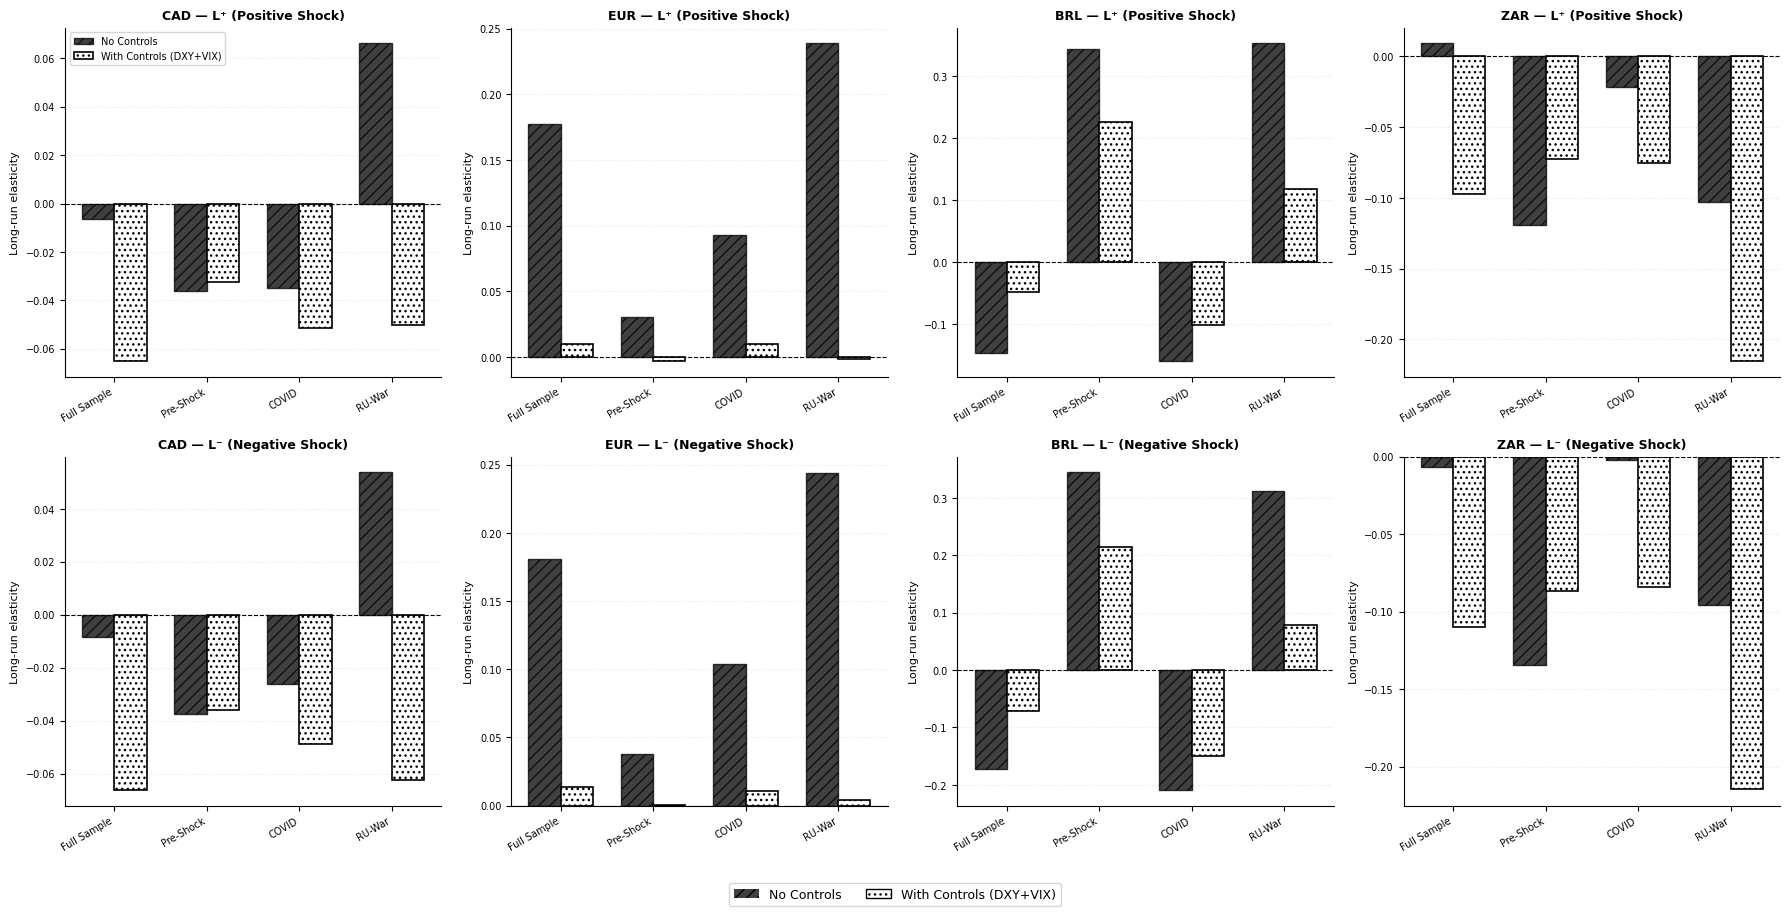

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 10c — FIGURE 3b: L+ AND L- COMPARISON (WITH vs WITHOUT CONTROLS)
# BLACK AND WHITE VERSION - NO TITLE IN IMAGE
# ══════════════════════════════════════════════════════════════════════════════

all_pn_keys  = ['Full Sample', 'Pre-Shock', 'COVID', 'RU-War']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for col, fx_var in enumerate(FX):
    for row, (shock_key, shock_label) in enumerate([
        ('Lpos', 'L⁺ (Positive Shock)'),
        ('Lneg', 'L⁻ (Negative Shock)'),
    ]):
        ax = axes[row][col]
        vals_nc, vals_wc = [], []

        for pn in all_pn_keys:
            r_nc = nardl_nc.get((pn, fx_var), {})
            r_wc = nardl_store.get((pn, fx_var), {})
            vals_nc.append(r_nc.get(shock_key, np.nan))
            vals_wc.append(r_wc.get(shock_key, np.nan))

        x     = np.arange(len(all_pn_keys))
        width = 0.35

        # No Controls - black with diagonal hatch
        bars_nc = ax.bar(
            x - width/2, vals_nc, width,
            label='No Controls',
            color='black',
            hatch='///',
            alpha=0.75,
            edgecolor='black'
        )

        # With Controls - white with dot hatch
        bars_wc = ax.bar(
            x + width/2, vals_wc, width,
            label='With Controls (DXY+VIX)',
            color='white',
            hatch='...',
            alpha=1.0,
            edgecolor='black',
            linewidth=1.2
        )

        ax.axhline(0, color='black', lw=0.8, ls='--')
        ax.set_title(
            f'{SHORT[fx_var]} — {shock_label}',
            fontsize=9, fontweight='bold'
        )
        ax.set_xticks(x)
        ax.set_xticklabels(
            all_pn_keys, rotation=30,
            ha='right', fontsize=7
        )
        ax.set_ylabel('Long-run elasticity', fontsize=8)
        ax.tick_params(axis='both', labelsize=7)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.yaxis.grid(True, alpha=0.3, linestyle=':')
        ax.set_axisbelow(True)

        if row == 0 and col == 0:
            ax.legend(fontsize=7, frameon=True)

# ── NO TITLE IN IMAGE ─────────────────────────────────────────────────────────
# Title removed - add in document above or below figure

# ── Shared legend at bottom ───────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_patches = [
    Patch(facecolor='black', hatch='///',
          alpha=0.75, label='No Controls'),
    Patch(facecolor='white', hatch='...',
          edgecolor='black', label='With Controls (DXY+VIX)')
]
fig.legend(
    handles=legend_patches,
    loc='lower center',
    ncol=2,
    fontsize=9,
    frameon=True,
    bbox_to_anchor=(0.5, -0.02)
)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig(
    'outputs/fig3b_nardl_comparison_bw.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()
print("Figure 3b saved - black and white, no title.")

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/fig3_multipliers_bw.png'

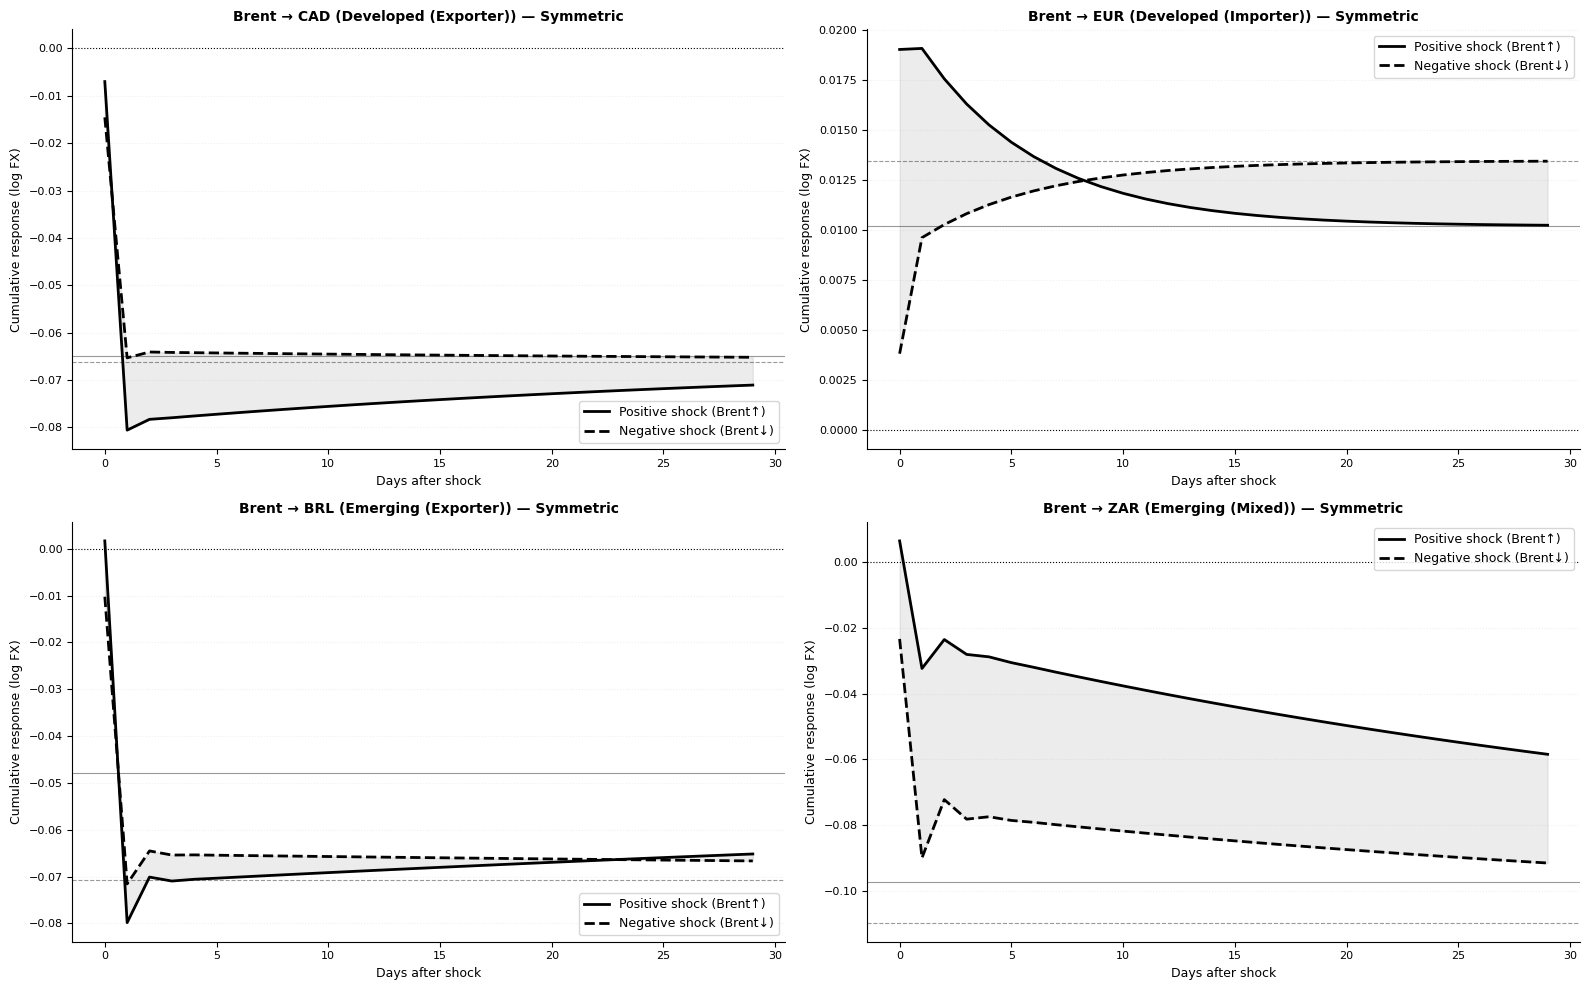

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 11 — DYNAMIC MULTIPLIERS (ASYMMETRIC IMPULSE ANALYSIS)
# BLACK AND WHITE VERSION - NO TITLE IN IMAGE
# ══════════════════════════════════════════════════════════════════════════════

def dynamic_multiplier(res, shock='pos', H=30):
    params = res['model'].params
    p = res.get('p', 2); q = res.get('q', 2)
    rho  = params.get('y_l1', 0)
    phi  = [params.get(f'dy_l{i}', 0) for i in range(1, p+1)]

    if shock == 'pos':
        lam   = [params.get(f'dxp_l{i}', 0) for i in range(0, q+1)]
        theta = params.get('xp_l1', 0)
    else:
        lam   = [params.get(f'dxn_l{i}', 0) for i in range(0, q+1)]
        theta = params.get('xn_l1', 0)

    H2  = H + 2
    dy  = np.zeros(H2)
    y   = np.zeros(H2)
    dx  = np.zeros(H2)
    x   = np.zeros(H2)

    dx[1] = 1.0
    x[1:] = 1.0

    for t in range(1, H2):
        ar_part = sum(phi[i-1] * dy[t-i] for i in range(1, min(p+1, t+1)))
        lm_part = sum(lam[i]   * dx[t-i] for i in range(0, min(q+1, t+1)) if t-i >= 0)
        dy[t]   = rho * y[t-1] + theta * x[t-1] + ar_part + lm_part
        y[t]    = y[t-1] + dy[t]

    return y[1:H+1]

# ── Plot dynamic multipliers ──────────────────────────────────────────────────
H    = 30
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, fx_var in zip(axes, FX):
    key = ('Full Sample', fx_var)
    if key not in nardl_store:
        ax.set_title(f'Brent-{SHORT[fx_var]}: No result')
        continue

    res  = nardl_store[key]
    mp   = dynamic_multiplier(res, shock='pos', H=H)
    mn   = dynamic_multiplier(res, shock='neg', H=H)
    days = np.arange(H)

    # Positive shock - solid black line
    ax.plot(days, mp,
            color='black',
            lw=2,
            linestyle='-',
            label='Positive shock (Brent↑)')

    # Negative shock - dashed black line
    ax.plot(days, mn,
            color='black',
            lw=2,
            linestyle='--',
            label='Negative shock (Brent↓)')

    # Fill between - light grey
    ax.fill_between(days, mp, mn,
                    alpha=0.15,
                    color='grey')

    # Zero line
    ax.axhline(0, color='black', lw=0.8, ls=':')

    # Long-run level reference lines
    Lp = res.get('Lpos', np.nan)
    Ln = res.get('Lneg', np.nan)
    if not np.isnan(Lp):
        ax.axhline(Lp, color='black', lw=0.8,
                   ls='-', alpha=0.4)
    if not np.isnan(Ln):
        ax.axhline(Ln, color='black', lw=0.8,
                   ls='--', alpha=0.4)

    # Asymmetry label
    wald_p = res.get('wald_p', 1.0)
    if wald_p < 0.01:
        asym_label = 'Asymmetric ***'
    elif wald_p < 0.05:
        asym_label = 'Asymmetric **'
    elif wald_p < 0.10:
        asym_label = 'Asymmetric *'
    else:
        asym_label = 'Symmetric'

    ax.set_title(
        f'Brent → {SHORT[fx_var]} ({FX_TYPE[fx_var]}) — {asym_label}',
        fontweight='bold', fontsize=10
    )
    ax.set_xlabel('Days after shock', fontsize=9)
    ax.set_ylabel('Cumulative response (log FX)', fontsize=9)
    ax.legend(fontsize=9, frameon=True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=8)
    ax.yaxis.grid(True, alpha=0.2, linestyle=':')
    ax.set_axisbelow(True)

# ── NO TITLE IN IMAGE ─────────────────────────────────────────────────────────
# Title removed - add in document above or below figure

plt.tight_layout()
plt.savefig(
    'outputs/fig3_multipliers_bw.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()
print("Figure 3 saved - black and white, no title.")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 13 — SUB-PERIOD NARDL COMPARISON
# ══════════════════════════════════════════════════════════════════════════════
sub_rows = []
for pn in PERIOD_ORDER:
    for fx_var in FX:
        key = (pn, fx_var)
        res = nardl_store.get(key, None)
        if res is None: continue
        p_   = res['lr_p']
        asig = ('***' if p_<.01 else '**' if p_<.05 else '*' if p_<.10 else 'No') if not np.isnan(p_) else '—'
        f_   = res['bounds_F']
        cv0, cv1 = BOUNDS_CV[0.05]
        if np.isnan(f_):   bdec = '—'
        elif f_ > cv1:     bdec = 'CI (5%)'
        elif f_ > cv0:     bdec = 'Incon.'
        else:              bdec = 'No CI'
        sub_rows.append({
            'Period'  : PERIOD_SHORT.get(pn, pn[:10]),
            'Pair'    : f"Brent-{SHORT[fx_var]}",
            'Economy' : FX_TYPE[fx_var],
            'L+'      : round(res['Lpos'],4) if not np.isnan(res['Lpos']) else '—',
            'L-'      : round(res['Lneg'],4) if not np.isnan(res['Lneg']) else '—',
            'Bounds F': round(f_,3)          if not np.isnan(f_)          else '—',
            'LR Rel.' : bdec,
            'Asymmetry': asig,
            'N'       : res['n'],
        })

df_sub = pd.DataFrame(sub_rows)
print("Table 10: Sub-Period NARDL Comparison")
print("="*105)
print(df_sub.to_string(index=False))
print("\nL+/L-: long-run elasticities for positive/negative Brent shocks.")
print("Asymmetry: Wald test for H0: L+=L-. */**/***=10%/5%/1%. Controls: DXY, VIX.")


Table 10: Sub-Period NARDL Comparison
Empty DataFrame
Columns: []
Index: []

L+/L-: long-run elasticities for positive/negative Brent shocks.
Asymmetry: Wald test for H0: L+=L-. */**/***=10%/5%/1%. Controls: DXY, VIX.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 13 — SUB-PERIOD NARDL COMPARISON
# ══════════════════════════════════════════════════════════════════════════════
sub_rows = []
for pn in PERIOD_ORDER:
    for fx_var in FX:
        key = (pn, fx_var)
        res = nardl_store.get(key, None)
        if res is None: continue
        p_   = res['lr_p']
        asig = ('***' if p_<.01 else '**' if p_<.05 else '*' if p_<.10 else 'No') if not np.isnan(p_) else '—'
        f_   = res['bounds_F']
        cv0, cv1 = BOUNDS_CV[0.05]
        if np.isnan(f_):   bdec = '—'
        elif f_ > cv1:     bdec = 'CI (5%)'
        elif f_ > cv0:     bdec = 'Incon.'
        else:              bdec = 'No CI'
        sub_rows.append({
            'Period'  : PERIOD_SHORT.get(pn, pn[:10]),
            'Pair'    : f"Brent-{SHORT[fx_var]}",
            'Economy' : FX_TYPE[fx_var],
            'L+'      : round(res['Lpos'],4) if not np.isnan(res['Lpos']) else '—',
            'L-'      : round(res['Lneg'],4) if not np.isnan(res['Lneg']) else '—',
            'Bounds F': round(f_,3)          if not np.isnan(f_)          else '—',
            'LR Rel.' : bdec,
            'Asymmetry': asig,
            'N'       : res['n'],
        })

df_sub = pd.DataFrame(sub_rows)
print("Table 10: Sub-Period NARDL Comparison")
print("="*105)
print(df_sub.to_string(index=False))
print("\nL+/L-: long-run elasticities for positive/negative Brent shocks.")
print("Asymmetry: Wald test for H0: L+=L-. */**/***=10%/5%/1%. Controls: DXY, VIX.")


Table 10: Sub-Period NARDL Comparison
Empty DataFrame
Columns: []
Index: []

L+/L-: long-run elasticities for positive/negative Brent shocks.
Asymmetry: Wald test for H0: L+=L-. */**/***=10%/5%/1%. Controls: DXY, VIX.


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/fig4_elasticities_bw.png'

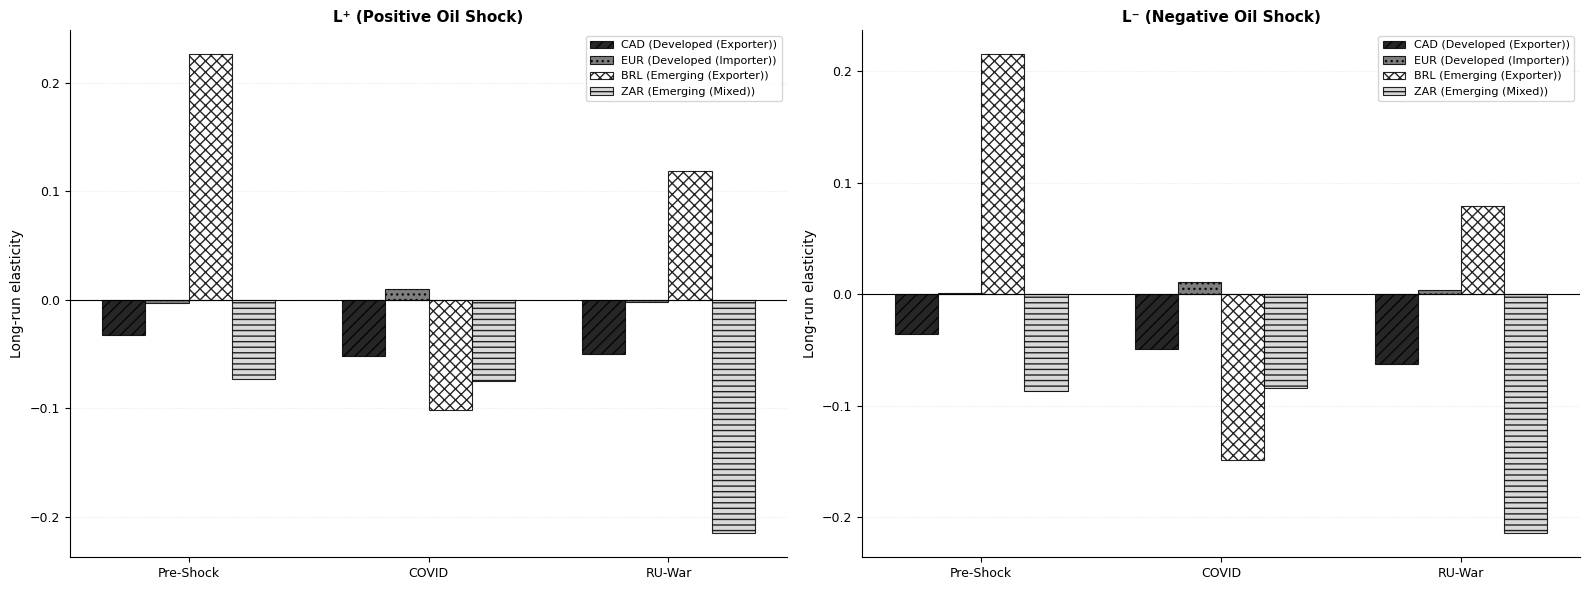

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 14 — FIGURE 4: SUB-PERIOD ELASTICITY COMPARISON
# BLACK AND WHITE VERSION - NO TITLE IN IMAGE
# ══════════════════════════════════════════════════════════════════════════════

PERIOD_ORDER_SHORT = ['Pre-Shock', 'COVID', 'RU-War']
pshort = PERIOD_ORDER_SHORT

# Black and white styles for each currency
BW_BAR_STYLES = {
    'CAD': {'color': 'black',      'hatch': '///'},
    'EUR': {'color': 'dimgray',    'hatch': '...'},
    'BRL': {'color': 'white',      'hatch': 'xxx'},
    'ZAR': {'color': 'lightgray',  'hatch': '---'},
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x    = np.arange(len(PERIOD_ORDER_SHORT))
w    = 0.18
offs = np.linspace(-1.5, 1.5, len(FX)) * w

for ax, shock, title in zip(
    axes,
    ['Lpos', 'Lneg'],
    ['L⁺ (Positive Oil Shock)', 'L⁻ (Negative Oil Shock)']
):
    for i, fx_var in enumerate(FX):
        short = SHORT[fx_var]
        style = BW_BAR_STYLES[short]
        vals  = []

        for pn in PERIOD_ORDER_SHORT:
            res = nardl_store.get((pn, fx_var), {})
            v   = res.get(shock, np.nan)
            vals.append(float(v) if not np.isnan(v) else 0.0)

        ax.bar(
            x + offs[i], vals, w,
            label=f"{short} ({FX_TYPE[fx_var]})",
            color=style['color'],
            hatch=style['hatch'],
            alpha=0.85,
            edgecolor='black',
            linewidth=0.8
        )

    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(pshort, fontsize=10)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('Long-run elasticity', fontsize=10)
    ax.tick_params(axis='both', labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, alpha=0.3, linestyle=':')
    ax.set_axisbelow(True)
    ax.legend(fontsize=8, frameon=True)

# ── NO TITLE IN IMAGE ─────────────────────────────────────────────────────────
# Title removed - add in document above or below figure

plt.tight_layout()
plt.savefig(
    'outputs/fig4_elasticities_bw.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()
print("Figure 4 saved - black and white, no title.")

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/fig5_multipliers_bw.png'

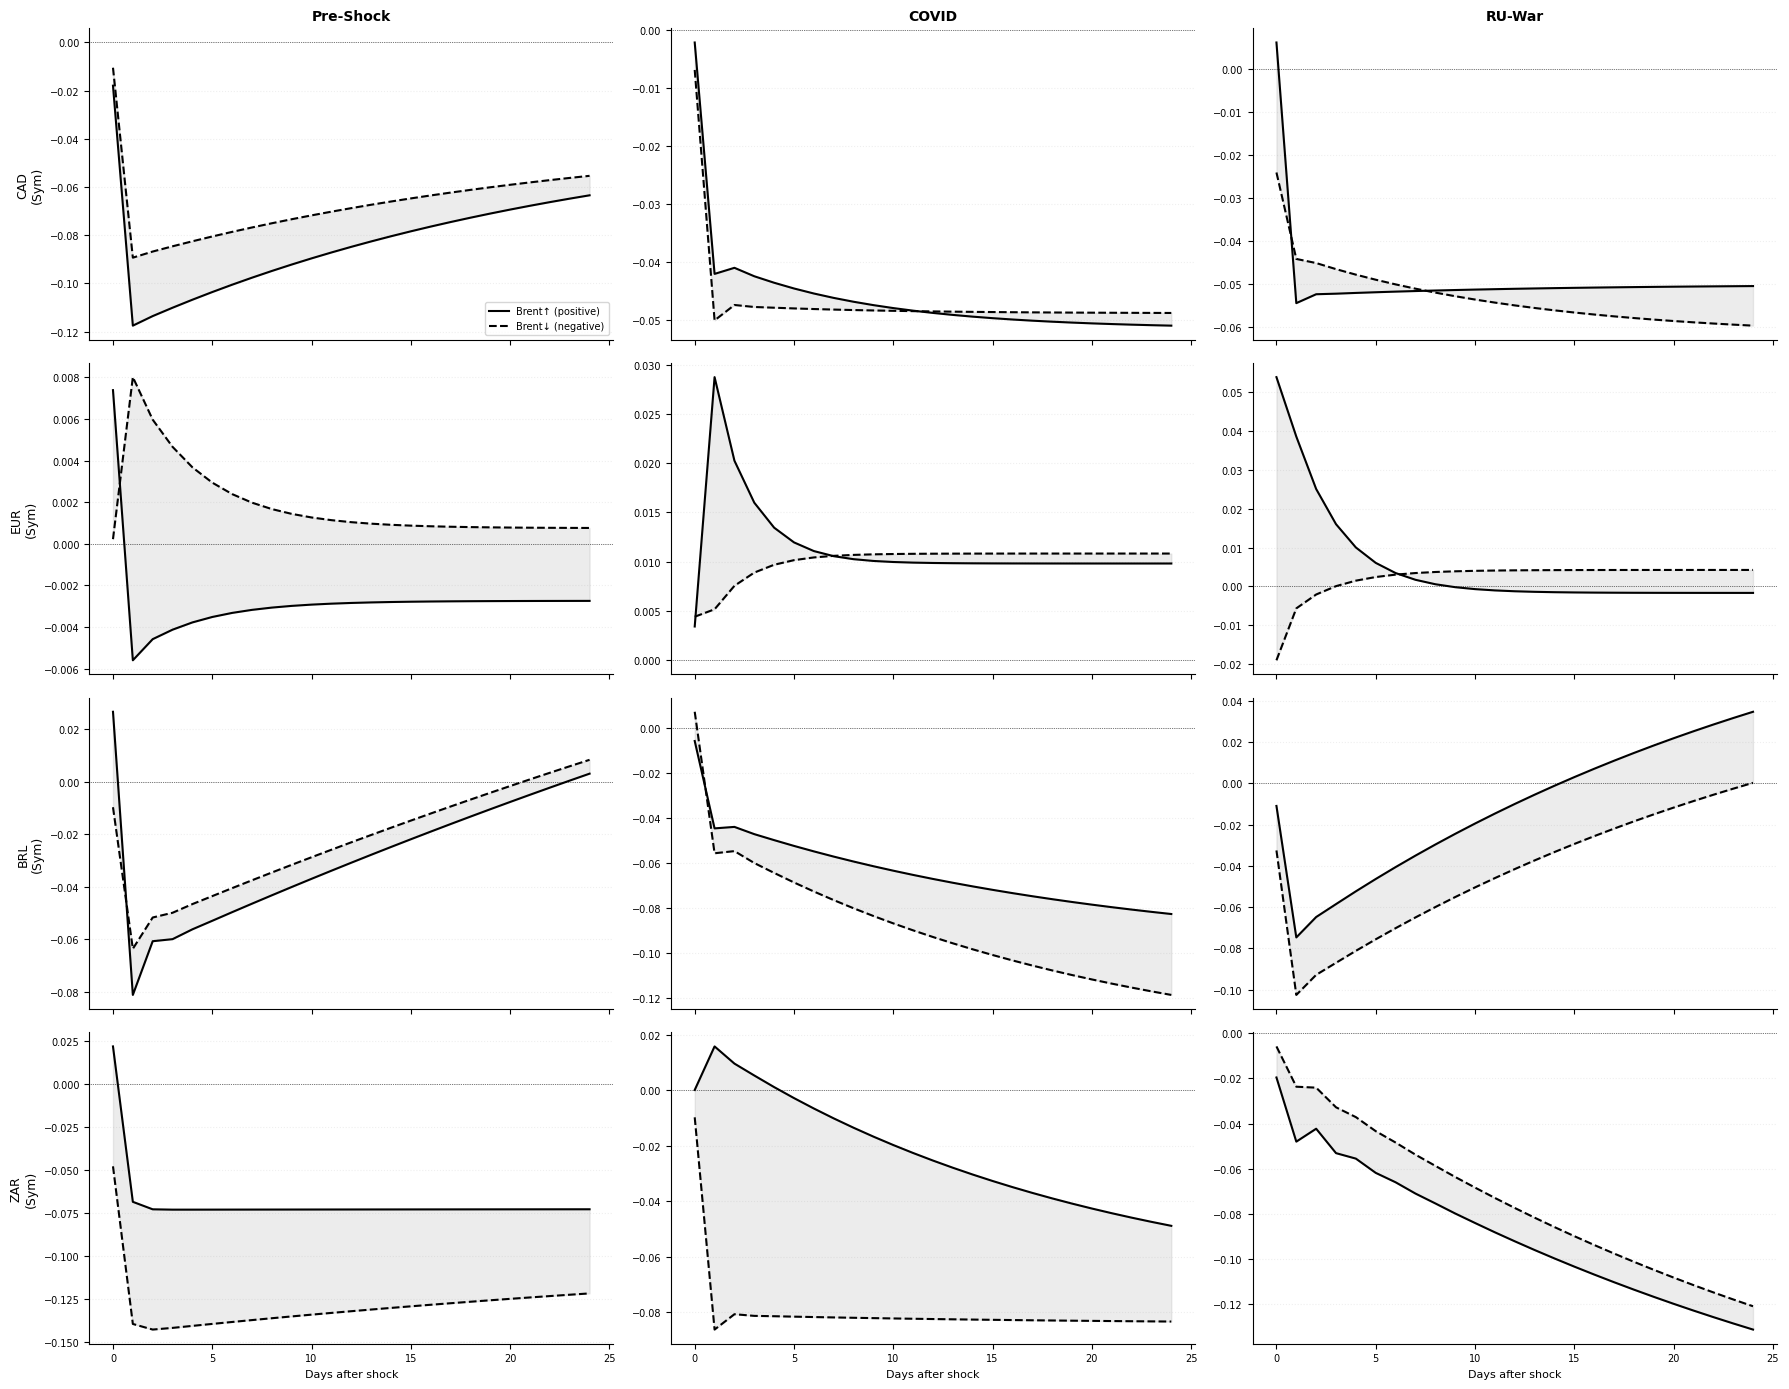

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 15 — FIGURE 5: DYNAMIC MULTIPLIERS ACROSS PERIODS
# BLACK AND WHITE VERSION - NO TITLE IN IMAGE
# ══════════════════════════════════════════════════════════════════════════════

H = 25
PERIOD_ORDER_SHORT = ['Pre-Shock', 'COVID', 'RU-War']
PERIOD_LABELS      = ['Pre-Shock', 'COVID', 'RU-War']

fig, axes = plt.subplots(len(FX), len(PERIOD_ORDER_SHORT),
                          figsize=(18, 14), sharex=True)

for row, fx_var in enumerate(FX):
    for col, pn in enumerate(PERIOD_ORDER_SHORT):
        ax  = axes[row][col]
        key = (pn, fx_var)
        res = nardl_store.get(key)

        if res is None or res['n'] == 0:
            ax.set_visible(False)
            continue

        mp = dynamic_multiplier(res, shock='pos', H=H)
        mn = dynamic_multiplier(res, shock='neg', H=H)
        d  = np.arange(H)

        # Positive shock - solid black line
        ax.plot(d, mp,
                color='black',
                lw=1.5,
                linestyle='-',
                label='Brent↑ (positive)')

        # Negative shock - dashed black line
        ax.plot(d, mn,
                color='black',
                lw=1.5,
                linestyle='--',
                label='Brent↓ (negative)')

        # Fill between - light grey shading
        ax.fill_between(d, mp, mn,
                        alpha=0.15,
                        color='grey')

        ax.axhline(0, color='black', lw=0.5, ls=':')

        # Asymmetry label
        wald_p = res.get('wald_p', 1.0)
        if wald_p < 0.01:
            asym_label = 'Asym ***'
        elif wald_p < 0.05:
            asym_label = 'Asym **'
        elif wald_p < 0.10:
            asym_label = 'Asym *'
        else:
            asym_label = 'Sym'

        # Column titles - top row only
        if row == 0:
            ax.set_title(PERIOD_LABELS[col],
                         fontweight='bold', fontsize=10)

        # Row labels - first column only
        if col == 0:
            ax.set_ylabel(f"{SHORT[fx_var]}\n({asym_label})",
                         fontsize=9)

        # Legend - top left panel only
        if row == 0 and col == 0:
            ax.legend(fontsize=7, frameon=True)

        # Clean styling
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='both', labelsize=7)
        ax.yaxis.grid(True, alpha=0.2, linestyle=':')
        ax.set_axisbelow(True)

# ── X axis label on bottom row ────────────────────────────────────────────────
for col in range(len(PERIOD_ORDER_SHORT)):
    axes[-1][col].set_xlabel('Days after shock', fontsize=8)

# ── NO TITLE IN IMAGE ─────────────────────────────────────────────────────────
# Title removed - add in document above or below figure

plt.tight_layout()
plt.savefig(
    'outputs/fig5_multipliers_bw.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()
print("Figure 5 saved - black and white, no title.")

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/fig_a5_markov_bw.png'

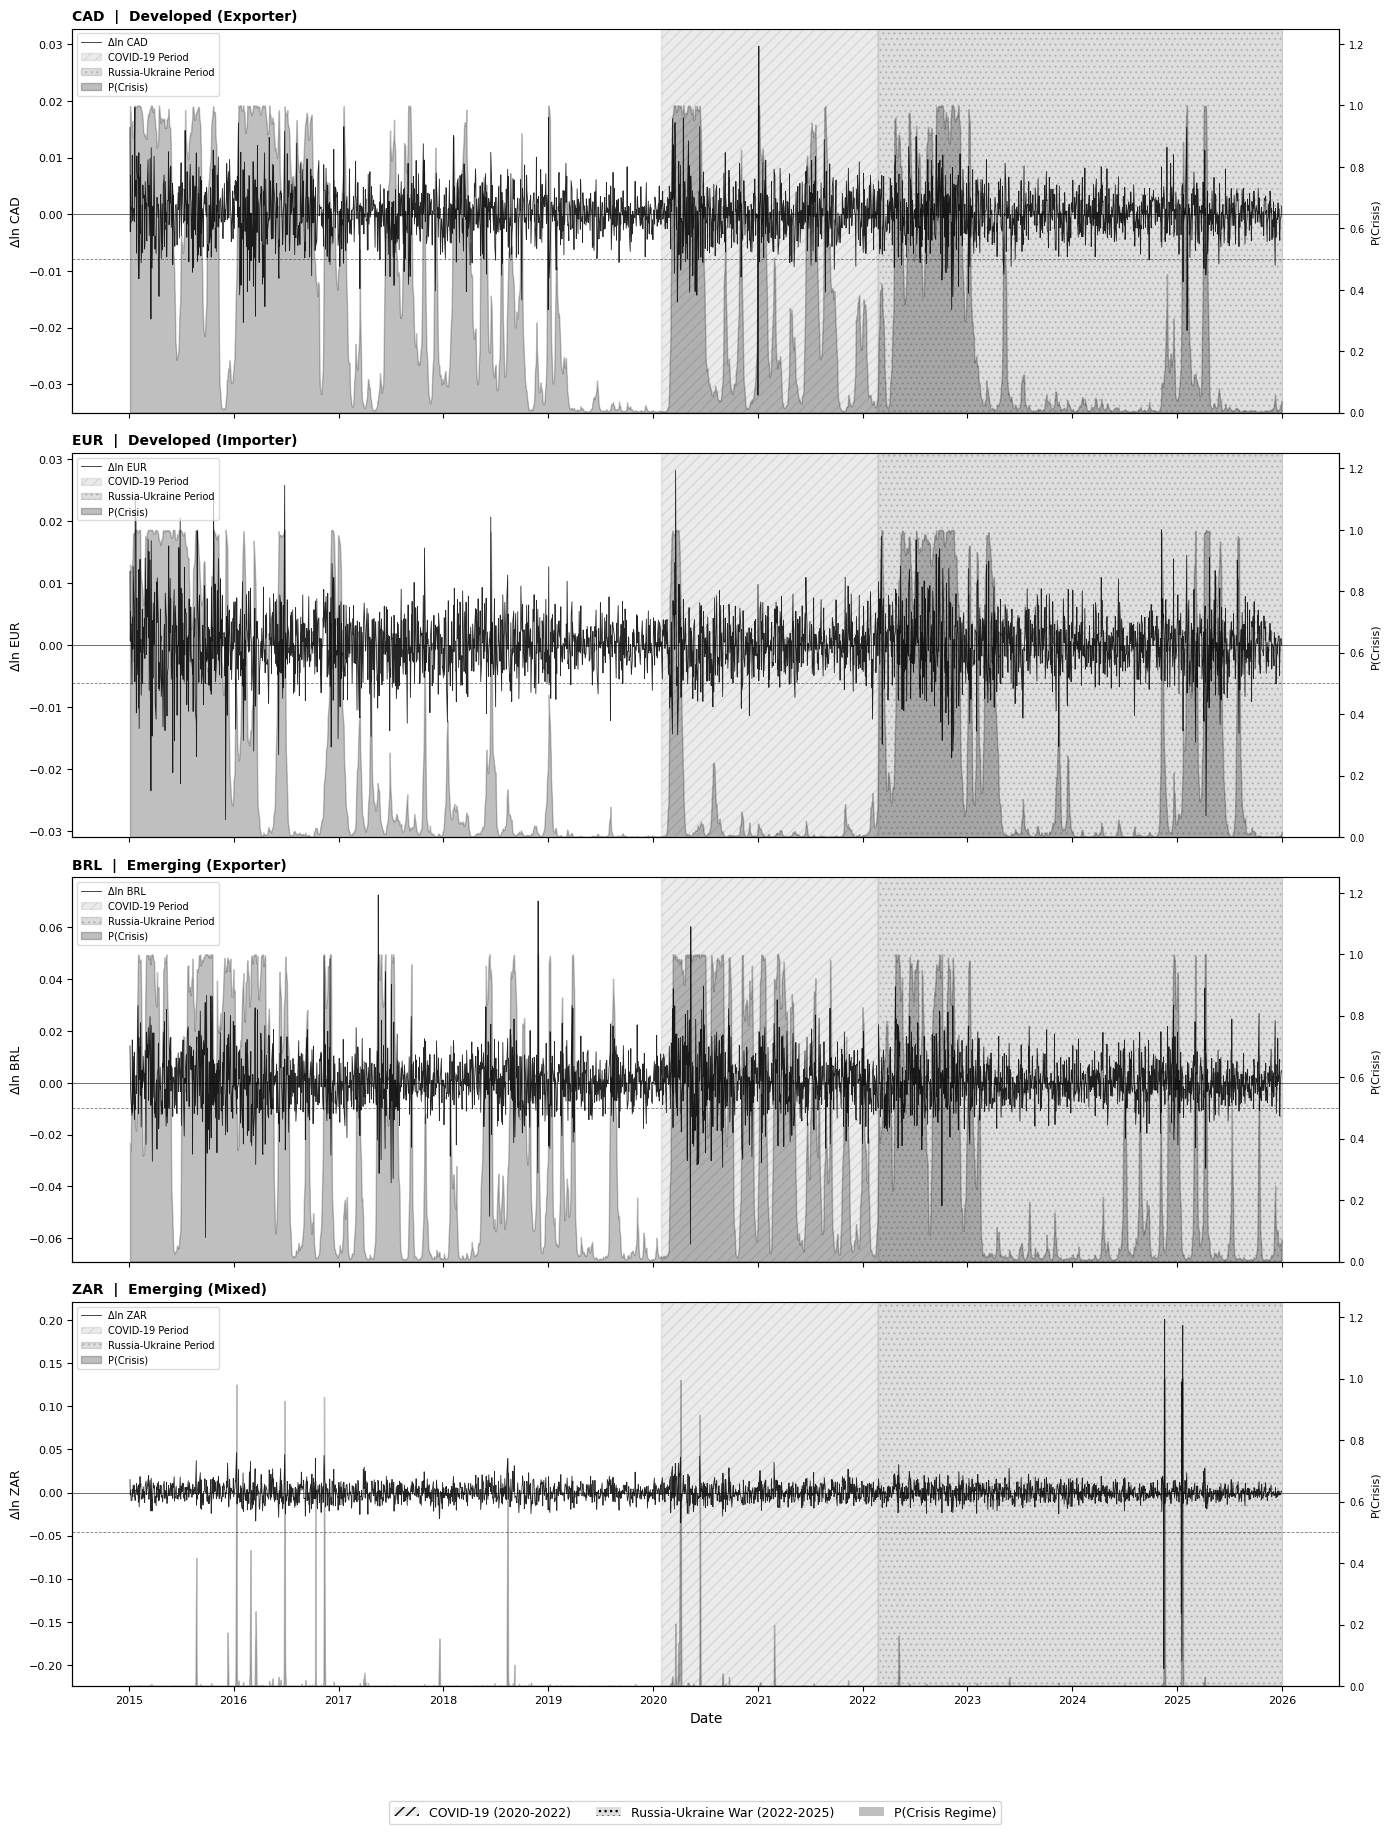

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 17 — MARKOV SWITCHING: SMOOTHED PROBABILITY PLOTS
# BLACK AND WHITE VERSION - NO TITLE IN IMAGE
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

ret_plot = log_data.diff().dropna()

fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True)

# ── NO TITLE IN IMAGE ─────────────────────────────────────────────────────────
# Title removed - add in document above or below figure

for ax, fx in zip(axes, FX):
    short = SHORT[fx]
    res   = ms_results[short]

    # ── Smoothed marginal probabilities ──────────────────────────────────────
    smooth = res.smoothed_marginal_probabilities
    if hasattr(smooth, 'values'):
        smooth = smooth.values

    prob_r0 = smooth[:, 0]
    prob_r1 = smooth[:, 1]

    # Identify high-volatility regime by larger fitted variance
    params_s = pd.Series(res.params.values, index=res.model.param_names)
    sv = []
    for r in range(N_REGIMES):
        val = np.nan
        for tag in [f'sigma2[{r}]', f'h.{r}', f'var[{r}]']:
            if tag in params_s.index:
                val = abs(params_s[tag]); break
        sv.append(val)
    high_regime = int(np.nanargmax(sv))
    prob_high   = smooth[:, high_regime]
    dates = ret_plot.index[-len(prob_high):]

    # ── Twin axis: regime probability (black and white) ───────────────────────
    ax2 = ax.twinx()
    ax2.fill_between(dates, prob_high,
                     alpha=0.25,
                     color='black',
                     label='P(Crisis)')
    ax2.axhline(0.5, color='black', lw=0.6, ls='--', alpha=0.5)
    ax2.set_ylim(0, 1.25)
    ax2.set_ylabel('P(Crisis)', fontsize=8)
    ax2.tick_params(axis='y', labelsize=7)

    # ── FX log-return - black solid line ─────────────────────────────────────
    ax.plot(dates, ret_plot.loc[dates, fx],
            color='black', lw=0.6, alpha=0.85,
            label=f'Δln {short}')
    ax.axhline(0, color='black', lw=0.4, ls='-')

    # ── Period shading - different grey intensities ───────────────────────────
    ax.axvspan(pd.Timestamp('2020-01-30'),
               pd.Timestamp('2022-02-21'),
               alpha=0.08, color='black',
               hatch='///', zorder=0,
               label='COVID-19 Period')
    ax.axvspan(pd.Timestamp('2022-02-22'),
               pd.Timestamp('2025-12-31'),
               alpha=0.13, color='black',
               hatch='...', zorder=0,
               label='Russia-Ukraine Period')

    # ── Axis labels and title ─────────────────────────────────────────────────
    ax.set_ylabel(f'Δln {short}', fontsize=9)
    ax.set_title(
        f'{short}  |  {FX_TYPE[fx]}',
        fontsize=10, fontweight='bold', loc='left'
    )
    ax.spines['top'].set_visible(False)
    ax.tick_params(axis='both', labelsize=8)

    # ── Legend combining both axes ────────────────────────────────────────────
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2,
              fontsize=7, loc='upper left', framealpha=0.7)

# ── Period legend at bottom ───────────────────────────────────────────────────
period_legend = [
    mpatches.Patch(facecolor='black', alpha=0.08,
                   hatch='///', label='COVID-19 (2020-2022)'),
    mpatches.Patch(facecolor='black', alpha=0.13,
                   hatch='...', label='Russia-Ukraine War (2022-2025)'),
    mpatches.Patch(facecolor='black', alpha=0.25,
                   label='P(Crisis Regime)')
]
fig.legend(handles=period_legend,
           loc='lower center',
           ncol=3,
           fontsize=9,
           frameon=True,
           bbox_to_anchor=(0.5, -0.02))

# ── X axis formatting ─────────────────────────────────────────────────────────
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].set_xlabel('Date', fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('outputs/fig_a5_markov_bw.png',
            dpi=150,
            bbox_inches='tight',
            facecolor='white')
plt.show()
print("Figure A5 saved - black and white, no title.")

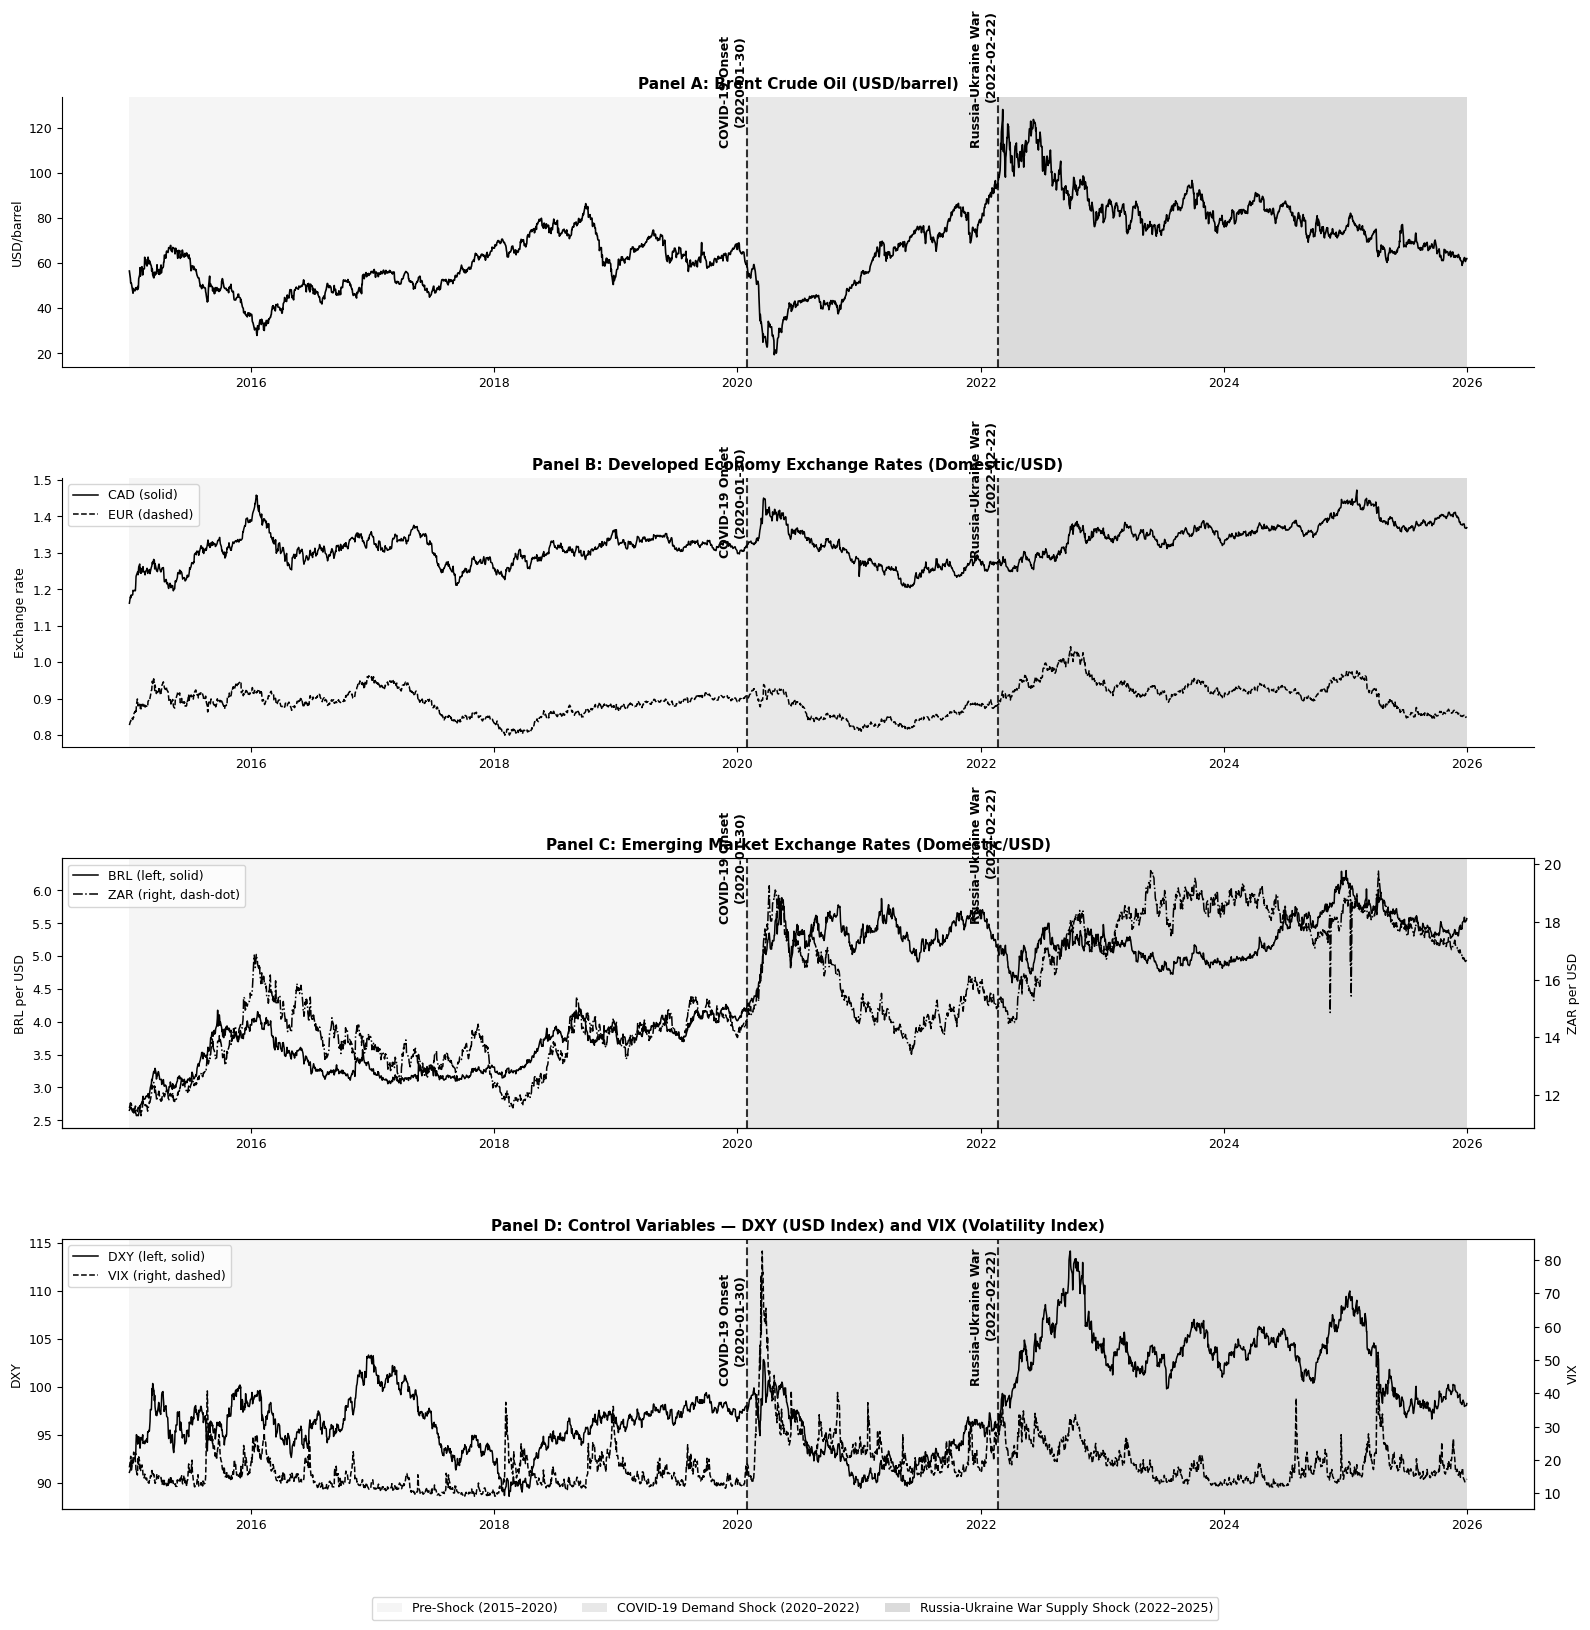

Figure 1 saved - black and white, 4 panels, no title.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4 — FIGURE 1: TIME-SERIES PLOTS (BLACK AND WHITE, NO TITLE)
# ══════════════════════════════════════════════════════════════════════════════
from matplotlib.patches import Patch

# Define break dates for vertical lines
BREAK_DATES = {
    'COVID-19 Onset\n(2020-01-30)':    pd.Timestamp('2020-01-30'),
    'Russia-Ukraine War\n(2022-02-22)': pd.Timestamp('2022-02-22'),
}

# Black and white line styles
BW_STYLES = {
    'Brent': {'color': 'black', 'lw': 1.2, 'linestyle': '-'},
    'CAD':   {'color': 'black', 'lw': 1.1, 'linestyle': '-'},
    'EUR':   {'color': 'black', 'lw': 1.1, 'linestyle': '--'},
    'BRL':   {'color': 'black', 'lw': 1.1, 'linestyle': '-'},
    'ZAR':   {'color': 'black', 'lw': 1.1, 'linestyle': '-.'},
    'DXY':   {'color': 'black', 'lw': 1.1, 'linestyle': '-'},
    'VIX':   {'color': 'black', 'lw': 1.1, 'linestyle': '--'},
}

# Black and white period shading
PERIOD_SHADES = {
    list(PERIOD_BOUNDS.keys())[0]: {'color': 'black', 'alpha': 0.04},
    list(PERIOD_BOUNDS.keys())[1]: {'color': 'black', 'alpha': 0.09},
    list(PERIOD_BOUNDS.keys())[2]: {'color': 'black', 'alpha': 0.14},
}

def add_period_shading(ax):
    """Add black and white period shading to any axis."""
    for name, (s, e) in PERIOD_BOUNDS.items():
        shade = PERIOD_SHADES[name]
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e),
                   alpha=shade['alpha'],
                   color=shade['color'],
                   linewidth=0)

def add_break_lines(ax, y_max, y_pos_ratio=0.88):
    """Add vertical break lines with labels."""
    for ev, dt in BREAK_DATES.items():
        ax.axvline(dt, color='black', ls='--',
                   lw=1.5, alpha=0.8)
        ax.text(dt, y_max * y_pos_ratio, ev,
                rotation=90, color='black',
                fontsize=9, ha='right',
                fontweight='bold')

def style_axis(ax):
    """Apply consistent axis styling."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=9)

# ── Create figure ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(16, 16))

# ── Panel A: Brent Crude Oil ──────────────────────────────────────────────────
ax = axes[0]
s = BW_STYLES['Brent']
ax.plot(raw.index, raw['Brent'],
        color=s['color'], lw=s['lw'], linestyle=s['linestyle'])
add_period_shading(ax)
add_break_lines(ax, raw['Brent'].max())
ax.set_title('Panel A: Brent Crude Oil (USD/barrel)',
             fontweight='bold', fontsize=11)
ax.set_ylabel('USD/barrel', fontsize=9)
style_axis(ax)

# ── Panel B: Developed Economy FX ────────────────────────────────────────────
ax = axes[1]
for fx, ls_key in [('CAD', 'CAD'), ('EUR', 'EUR')]:
    s = BW_STYLES[ls_key]
    ax.plot(raw.index, raw[fx],
            color=s['color'],
            lw=s['lw'],
            linestyle=s['linestyle'],
            label=f'{fx} (solid)' if s['linestyle'] == '-' else f'{fx} (dashed)')
add_period_shading(ax)
add_break_lines(ax, max(raw['CAD'].max(), raw['EUR'].max()))
ax.set_title('Panel B: Developed Economy Exchange Rates (Domestic/USD)',
             fontweight='bold', fontsize=11)
ax.set_ylabel('Exchange rate', fontsize=9)
ax.legend(loc='upper left', fontsize=9, frameon=True)
style_axis(ax)

# ── Panel C: Emerging Market FX ───────────────────────────────────────────────
ax = axes[2]
ax2 = ax.twinx()

s_brl = BW_STYLES['BRL']
s_zar = BW_STYLES['ZAR']

ax.plot(raw.index, raw['BRL'],
        color=s_brl['color'],
        lw=s_brl['lw'],
        linestyle=s_brl['linestyle'],
        label='BRL (left, solid)')
ax2.plot(raw.index, raw['ZAR'],
         color=s_zar['color'],
         lw=s_zar['lw'],
         linestyle=s_zar['linestyle'],
         label='ZAR (right, dash-dot)')

add_period_shading(ax)
add_break_lines(ax, raw['BRL'].max())

ax.set_title('Panel C: Emerging Market Exchange Rates (Domestic/USD)',
             fontweight='bold', fontsize=11)
ax.set_ylabel('BRL per USD', fontsize=9)
ax2.set_ylabel('ZAR per USD', fontsize=9)
ax.spines['top'].set_visible(False)
ax.tick_params(axis='both', labelsize=9)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2,
          loc='upper left', fontsize=9, frameon=True)

# ── Panel D: Control Variables ────────────────────────────────────────────────
ax = axes[3]
ax2 = ax.twinx()

s_dxy = BW_STYLES['DXY']
s_vix = BW_STYLES['VIX']

ax.plot(raw.index, raw['DXY'],
        color=s_dxy['color'],
        lw=s_dxy['lw'],
        linestyle=s_dxy['linestyle'],
        label='DXY (left, solid)')
ax2.plot(raw.index, raw['VIX'],
         color=s_vix['color'],
         lw=s_vix['lw'],
         linestyle=s_vix['linestyle'],
         label='VIX (right, dashed)')

add_period_shading(ax)
add_break_lines(ax, raw['DXY'].max())

ax.set_title('Panel D: Control Variables — DXY (USD Index) and VIX (Volatility Index)',
             fontweight='bold', fontsize=11)
ax.set_ylabel('DXY', fontsize=9)
ax2.set_ylabel('VIX', fontsize=9)
ax.spines['top'].set_visible(False)
ax.tick_params(axis='both', labelsize=9)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2,
          loc='upper left', fontsize=9, frameon=True)

# ── Period legend at bottom ───────────────────────────────────────────────────
period_legend = [
    Patch(facecolor='black', alpha=0.04,
          label='Pre-Shock (2015–2020)'),
    Patch(facecolor='black', alpha=0.09,
          label='COVID-19 Demand Shock (2020–2022)'),
    Patch(facecolor='black', alpha=0.14,
          label='Russia-Ukraine War Supply Shock (2022–2025)'),
]
fig.legend(handles=period_legend,
           loc='lower center',
           ncol=3,
           fontsize=9,
           frameon=True,
           bbox_to_anchor=(0.5, -0.02))

# ── NO TITLE IN IMAGE ─────────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('/content/fig1_timeseries_bw.png',
            dpi=150,
            bbox_inches='tight',
            facecolor='white')
plt.show()
print("Figure 1 saved - black and white, 4 panels, no title.")

NameError: name 'sns' is not defined

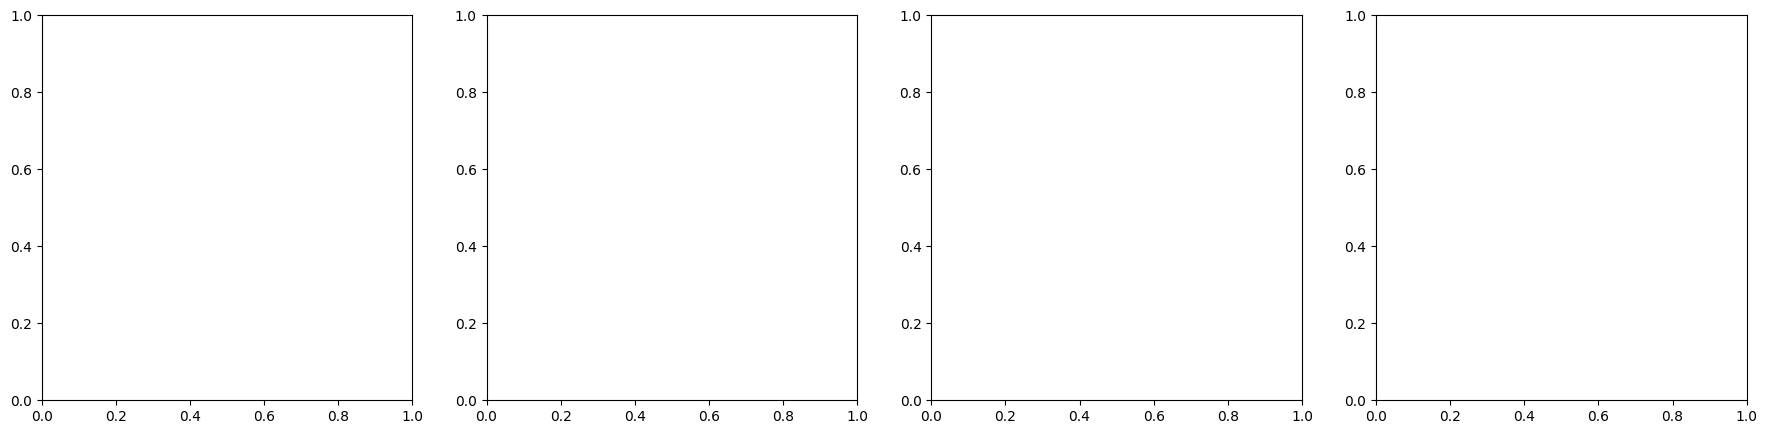

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 6 — CORRELATION HEATMAPS BY PERIOD
# BLACK AND WHITE VERSION - NO TITLE IN IMAGE
# ══════════════════════════════════════════════════════════════════════════════

pnames = ['Full Sample'] + list(PERIOD_BOUNDS.keys())

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, pn in zip(axes, pnames):
    df   = periods[pn]
    corr = df[[OIL] + FX].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    # Black and white colormap - light to dark grey
    sns.heatmap(
        corr,
        ax=ax,
        annot=True,
        fmt='.2f',
        cmap='Greys',        # black and white greyscale
        vmin=-1,
        vmax=1,
        mask=mask,
        linewidths=0.5,
        linecolor='white',
        xticklabels=['Brent', 'CAD', 'EUR', 'BRL', 'ZAR'],
        yticklabels=['Brent', 'CAD', 'EUR', 'BRL', 'ZAR'],
        annot_kws={'size': 9, 'color': 'black'},
        cbar_kws={'shrink': 0.8}
    )

    # Clean title - remove date part in parentheses
    ax.set_title(
        pn.split('(')[0].strip(),
        fontsize=10,
        fontweight='bold'
    )
    ax.tick_params(axis='both', labelsize=8)

# ── NO TITLE IN IMAGE ─────────────────────────────────────────────────────────
# Title removed - add in document above or below figure

plt.tight_layout()
plt.savefig(
    'outputs/fig2_correlations_bw.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()
print("Figure 2 saved - black and white, no title.")